# Full structured single-shot experiment: HK, FJ, and nonlinear influence

This is the confirmatory structured-mechanism experiment following the earlier
topology-discovery studies.

The topology families and parameter regions are **fixed before this run** from
the mechanism/oracle screens:

- Hegselmann--Krause: two confidence-separated communities connected only by
  their two central hubs;
- Friedkin--Johnsen: low-opinion broadcaster networks;
- nonlinear influence: low-opinion broadcaster networks with saturated
  nonlinear influence.

The learned controller is **not used to choose a topology in this notebook**.

## Experimental design

For each propagation model:

- 3 fixed structural families;
- 5 independently perturbed environment variants per family;
- 3 independent learned-identifier seeds per environment;
- 20 campaigns;
- campaign 0 passive;
- campaigns 1--19 pure learned exploitation;
- no explicit random exploration.

This gives:

- 15 distinct environments per propagation model;
- 45 distinct environments overall;
- 45 learned runs per propagation model;
- 135 learned runs overall.

Uniform, true-graph, and no-control baselines are computed once per distinct
environment and cached separately.

For statistical reporting, the 3 learning seeds are first averaged **within the
same environment**. Confidence intervals and environment-level win rates are
then computed across the 15 distinct environments per propagation model. This
avoids treating optimizer/RNG repetitions as independent graph samples.

## Why exploration is fixed to zero

The previous exploration sweep found no general, repeatable advantage from
spending early control campaigns on random exploration. In a 20-campaign
single-shot trajectory, every exploratory campaign also consumes scarce control
budget. This experiment therefore treats the previous exploration study as the
ablation and uses pure exploitation after the initial passive campaign.

The setting remains configurable in one place if a later reviewer requests an
additional sensitivity test.

In [1]:
from __future__ import annotations

import hashlib
import inspect
import json
import os
import random
import subprocess
import sys
import time
from datetime import datetime, timezone
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

pd.set_option("display.max_columns", 240)
pd.set_option("display.width", 280)


def find_repo_root(start: Path | None = None) -> Path:
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "opinion_dynamics").exists():
            return candidate
    raise RuntimeError(
        "Could not find repository root containing opinion_dynamics/."
    )


REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from rl_envs_forge.envs.network_graph.network_graph import NetworkGraph
from rl_envs_forge.envs.network_graph.graph_utils import (
    compute_eigenvector_centrality,
    compute_laplacian,
)
from opinion_dynamics.baseline import centrality_based_continuous_control
import opinion_dynamics.experiments.online_single_shot as online_single_shot_module

run_single_shot_online_identification = (
    online_single_shot_module.run_single_shot_online_identification
)

try:
    GIT_COMMIT = subprocess.run(
        ["git", "rev-parse", "--short", "HEAD"],
        cwd=REPO_ROOT,
        check=True,
        capture_output=True,
        text=True,
    ).stdout.strip()
except Exception:
    GIT_COMMIT = "unknown"

print("Repository root:", REPO_ROOT)
print("Git commit:", GIT_COMMIT)
print(
    "online_single_shot:",
    inspect.getsourcefile(online_single_shot_module),
)
print("NetworkGraph:", inspect.getsourcefile(NetworkGraph))

C:\Users\Chainsword\AppData\Local\Temp\ipykernel_34700\1989128471.py:17: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


Repository root: d:\Work\repos\RL\unknown_graph_networks
Git commit: ca3199a
online_single_shot: d:\Work\repos\RL\unknown_graph_networks\opinion_dynamics\experiments\online_single_shot.py
NetworkGraph: c:\Users\Chainsword\anaconda3\envs\phd_rl_algos\Lib\site-packages\rl_envs_forge\envs\network_graph\network_graph.py


## Configuration and fixed family definitions

In [2]:
# ---------------------------------------------------------------------------
# Parallel worker mode
# ---------------------------------------------------------------------------
NUM_SHARDS = 6
SHARD_ENV = "STRUCTURED_FULL_SHARD_ID"
THREAD_ENV = "STRUCTURED_FULL_TORCH_THREADS"

_shard_value = os.environ.get(SHARD_ENV)
WORKER_MODE = _shard_value is not None
SHARD_ID = int(_shard_value) if WORKER_MODE else None

if WORKER_MODE and SHARD_ID not in range(NUM_SHARDS):
    raise ValueError(
        f"{SHARD_ENV} must be in 0..{NUM_SHARDS - 1}; got {SHARD_ID}"
    )

TORCH_THREADS = int(os.environ.get(THREAD_ENV, "2"))
torch.set_num_threads(max(1, TORCH_THREADS))
try:
    torch.set_num_interop_threads(1)
except RuntimeError:
    pass

DEVICE = os.environ.get("STRUCTURED_FULL_DEVICE", "cpu").lower()
if DEVICE == "cuda" and not torch.cuda.is_available():
    raise RuntimeError("CUDA requested but unavailable.")

print("Mode:", "worker" if WORKER_MODE else "analysis")
if WORKER_MODE:
    print("Shard:", f"{SHARD_ID + 1}/{NUM_SHARDS}")
print("Device:", DEVICE)
print("Torch threads:", torch.get_num_threads())

# ---------------------------------------------------------------------------
# Common experiment settings
# ---------------------------------------------------------------------------
STUDY_NAME = "structured_mechanism_full_multiseed"
PIPELINE_VERSION = "2026-08-17-v1"

N = 15
TARGET = 1.0

NUM_CAMPAIGNS = 20
T_CAMPAIGN = 0.5
T_S = 0.1

MAX_U = 0.20
TOTAL_CONTROLLED_BUDGET = 6.0
B_CAMPAIGN = TOTAL_CONTROLLED_BUDGET / (NUM_CAMPAIGNS - 1)

LAMBDA_MIX = 0.70

# Confirmatory choice based on the previous exploration ablation:
EXPLORATION_CAMPAIGNS = 0
EPSILON_SCHEDULE = [0.0] * NUM_CAMPAIGNS

FIT_LR = 1e-3
FIT_MAX_STEPS = 1_000
FIT_MAE_STOP = 5e-4
FIT_BATCH_SIZE = 256
FIT_CHECK_EVERY = 200
IDENTIFIER_KWARGS = {"hidden_dim": 16}

ENVIRONMENT_SEEDS = [0, 1, 2, 3, 4]
LEARNING_SEEDS = [0, 1, 2]

# ---------------------------------------------------------------------------
# Dynamics settings fixed from the parameter screens
# ---------------------------------------------------------------------------
HK_EPSILON = 0.25
HK_INCLUDE_SELF = True
FJ_LAMBDA = 0.98
NONLINEAR_BETA = 4.0

# ---------------------------------------------------------------------------
# Fixed mechanism families
# ---------------------------------------------------------------------------
HK_FAMILIES = {
    # Original successful latent-bridge construction.
    "ring_bridge": {
        "peer_pattern": "ring",
        "hub_leaf_weight": 3.0,
        "peer_weight": 0.40,
        "bridge_weight": 3.0,
    },
    # Same latent bridge, different within-community peripheral topology.
    "paired_bridge": {
        "peer_pattern": "paired",
        "hub_leaf_weight": 3.0,
        "peer_weight": 0.55,
        "bridge_weight": 3.0,
    },
    # Same latent bridge with weak dense peripheral coupling.
    "dense_weak_bridge": {
        "peer_pattern": "dense",
        "hub_leaf_weight": 3.0,
        "peer_weight": 0.08,
        "bridge_weight": 3.0,
    },
}

BROADCAST_FAMILIES = {
    # These three families all showed strong oracle-vs-uniform gaps in the
    # discovery screens at total hub influence 0.85.
    "asymmetric_broadcast": {
        "kind": "asymmetric",
        "hub_influence_total": 0.85,
    },
    "split_broadcast": {
        "kind": "split",
        "hub_influence_total": 0.85,
    },
    "dual_broadcast": {
        "kind": "dual",
        "hub_influence_total": 0.85,
    },
}

# Discovery-screen base opinion settings.
FJ_HUB_LEVEL = 0.16
FJ_LEAF_LEVEL = 0.48
NLI_HUB_LEVEL = 0.10
NLI_LEAF_LEVEL = 0.50

# Mild confirmatory perturbations around the frozen families.
EDGE_WEIGHT_JITTER_FRAC = 0.05
HK_OPINION_JITTER = 0.006
BROADCAST_OPINION_JITTER = 0.010

# Results and persistent caches.
RESULTS_ROOT = (
    REPO_ROOT
    / "opinion_dynamics"
    / "experiments"
    / "results"
)
RESULTS_DIR = (
    RESULTS_ROOT
    / "experiment_2026_08_17_structured_mechanism_full_multiseed"
)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

CACHE_ROOT = (
    RESULTS_ROOT
    / "_trial_cache"
    / STUDY_NAME
)
CACHE_ROOT.mkdir(parents=True, exist_ok=True)

print("Campaign budget:", B_CAMPAIGN)
print("Uniform allocation/node:", B_CAMPAIGN / N)
print("Exploration campaigns:", EXPLORATION_CAMPAIGNS)
print("Environment seeds/family:", len(ENVIRONMENT_SEEDS))
print("Learning seeds/environment:", len(LEARNING_SEEDS))
print("Cache root:", CACHE_ROOT)

Mode: analysis
Device: cpu
Torch threads: 2
Campaign budget: 0.3157894736842105
Uniform allocation/node: 0.021052631578947368
Exploration campaigns: 0
Environment seeds/family: 5
Learning seeds/environment: 3
Cache root: d:\Work\repos\RL\unknown_graph_networks\opinion_dynamics\experiments\results\_trial_cache\structured_mechanism_full_multiseed


### Confirmatory family count

There are three fixed structural families for each dynamics model. Each family
is perturbed five times using a seed that changes both edge weights and initial
opinions while preserving the qualitative mechanism.

In [3]:
family_table = pd.DataFrame(
    [
        {
            "dynamics": "hegselmannkrause",
            "family": name,
            **params,
        }
        for name, params in HK_FAMILIES.items()
    ]
    + [
        {
            "dynamics": "friedkinjohnsen",
            "family": name,
            **params,
            "base_hub_level": FJ_HUB_LEVEL,
            "base_leaf_level": FJ_LEAF_LEVEL,
        }
        for name, params in BROADCAST_FAMILIES.items()
    ]
    + [
        {
            "dynamics": "nonlinearinfluence",
            "family": name,
            **params,
            "base_hub_level": NLI_HUB_LEVEL,
            "base_leaf_level": NLI_LEAF_LEVEL,
        }
        for name, params in BROADCAST_FAMILIES.items()
    ]
)

display(family_table)

,dynamics,family,peer_pattern,hub_leaf_weight,peer_weight,bridge_weight,kind,hub_influence_total,base_hub_level,base_leaf_level
0,hegselmannkrause,ring_bridge,ring,3.0,0.40,3.0,NaN,NaN,NaN,NaN
1,hegselmannkrause,paired_bridge,paired,3.0,0.55,3.0,NaN,NaN,NaN,NaN
2,hegselmannkrause,dense_weak_bridge,dense,3.0,0.08,3.0,NaN,NaN,NaN,NaN
3,friedkinjohnsen,asymmetric_broadcast,NaN,NaN,NaN,NaN,asymmetric,0.85,0.16,0.48
4,friedkinjohnsen,split_broadcast,NaN,NaN,NaN,NaN,split,0.85,0.16,0.48
5,friedkinjohnsen,dual_broadcast,NaN,NaN,NaN,NaN,dual,0.85,0.16,0.48
6,nonlinearinfluence,asymmetric_broadcast,NaN,NaN,NaN,NaN,asymmetric,0.85,0.10,0.50
7,nonlinearinfluence,split_broadcast,NaN,NaN,NaN,NaN,split,0.85,0.10,0.50
8,nonlinearinfluence,dual_broadcast,NaN,NaN,NaN,NaN,dual,0.85,0.10,0.50


## Environment cloning compatibility

The online runner recreates the environment from a template. This compatibility
layer explicitly preserves the HK, FJ, and nonlinear-influence parameters. It
is intentionally local to the notebook so the experiment remains reproducible
even if an older `online_single_shot.py` is checked out.

In [4]:
def _copy_maybe(value: Any) -> Any:
    if isinstance(value, np.ndarray):
        return np.array(value, copy=True)
    if isinstance(value, list):
        return list(value)
    if isinstance(value, tuple):
        return tuple(value)
    return value


def patched_env_kwargs_from_env(
    env: Any,
    *,
    t_campaign: float | None = None,
    t_s: float | None = None,
) -> dict[str, Any]:
    n = int(env.num_agents)

    kwargs = dict(
        connectivity_matrix=np.array(
            env.connectivity_matrix,
            copy=True,
        ),
        num_agents=n,
        max_u=np.array(env.max_u, copy=True),
        desired_opinion=float(env.desired_opinion),
        t_campaign=float(
            env.t_campaign if t_campaign is None else t_campaign
        ),
        t_s=float(env.t_s if t_s is None else t_s),
        dynamics_model=str(env.dynamics_model),
        initial_opinions=np.array(
            getattr(env, "initial_opinions", env.opinions),
            copy=True,
        ),
        control_resistance=np.array(
            getattr(env, "control_resistance", np.zeros(n)),
            copy=True,
        ),
        max_steps=int(getattr(env, "max_steps", 10_000)),
        opinion_end_tolerance=float(
            getattr(env, "opinion_end_tolerance", 0.01)
        ),
        control_beta=float(
            getattr(env, "control_beta", 0.4)
        ),
        normalize_reward=bool(
            getattr(env, "normalize_reward", True)
        ),
        terminal_reward=float(
            getattr(env, "terminal_reward", 0.0)
        ),
        terminate_when_converged=bool(
            getattr(env, "terminate_when_converged", False)
        ),
        budget=float(getattr(env, "budget", 1000.0)),
        seed=(
            int(env.seed)
            if getattr(env, "seed", None) is not None
            else None
        ),
    )

    model = str(env.dynamics_model).lower()

    if model == "hegselmannkrause":
        kwargs["hk_epsilon"] = float(env.hk_epsilon)
        kwargs["hk_include_self"] = bool(env.hk_include_self)

    elif model == "friedkinjohnsen":
        kwargs["fj_lambda"] = _copy_maybe(env.fj_lambda)
        kwargs["fj_prejudice"] = _copy_maybe(env.fj_prejudice)

    elif model == "nonlinearinfluence":
        kwargs["nonlinear_beta"] = float(env.nonlinear_beta)

    return kwargs


def patched_make_env_from_template(
    env_template: Any,
    *,
    t_campaign: float | None = None,
    t_s: float | None = None,
) -> Any:
    return env_template.__class__(
        **patched_env_kwargs_from_env(
            env_template,
            t_campaign=t_campaign,
            t_s=t_s,
        )
    )


online_single_shot_module.env_kwargs_from_env = (
    patched_env_kwargs_from_env
)
online_single_shot_module.make_env_from_template = (
    patched_make_env_from_template
)
run_single_shot_online_identification = (
    online_single_shot_module.run_single_shot_online_identification
)

print("Environment cloning compatibility layer installed.")

Environment cloning compatibility layer installed.


## Structured environment generators

In [5]:
HK_LOW_CLUSTER = tuple(range(0, 7))
HK_HIGH_CLUSTER = tuple(range(7, 15))
HK_LOW_HUB = 0
HK_HIGH_HUB = 7

BROADCAST_HUBS = (0, 1)
BROADCAST_LEAVES = tuple(range(2, N))
BROADCAST_GROUP_A = tuple(range(2, 8))
BROADCAST_GROUP_B = tuple(range(8, N))


def _normalize_rows(raw: np.ndarray) -> np.ndarray:
    raw = np.asarray(raw, dtype=float)
    np.fill_diagonal(raw, 0.0)
    sums = raw.sum(axis=1, keepdims=True)
    if np.any(sums <= 0):
        raise RuntimeError("Every graph row must have positive mass.")
    A = raw / sums
    np.fill_diagonal(A, 0.0)
    return A


def _jitter_positive_edges(
    raw: np.ndarray,
    rng: np.random.Generator,
    frac: float,
) -> np.ndarray:
    out = np.asarray(raw, dtype=float).copy()
    mask = out > 0
    multipliers = rng.uniform(
        1.0 - float(frac),
        1.0 + float(frac),
        size=out.shape,
    )
    out[mask] *= multipliers[mask]
    np.fill_diagonal(out, 0.0)
    return out


def _add_undirected(
    raw: np.ndarray,
    i: int,
    j: int,
    weight: float,
) -> None:
    raw[i, j] += float(weight)
    raw[j, i] += float(weight)


def build_hk_graph(
    family_name: str,
    environment_seed: int,
) -> tuple[np.ndarray, np.ndarray]:
    params = HK_FAMILIES[family_name]
    raw = np.zeros((N, N), dtype=float)

    for node in HK_LOW_CLUSTER:
        if node != HK_LOW_HUB:
            _add_undirected(
                raw,
                HK_LOW_HUB,
                node,
                params["hub_leaf_weight"],
            )

    for node in HK_HIGH_CLUSTER:
        if node != HK_HIGH_HUB:
            _add_undirected(
                raw,
                HK_HIGH_HUB,
                node,
                params["hub_leaf_weight"],
            )

    for cluster, hub in [
        (HK_LOW_CLUSTER, HK_LOW_HUB),
        (HK_HIGH_CLUSTER, HK_HIGH_HUB),
    ]:
        leaves = [node for node in cluster if node != hub]
        pattern = params["peer_pattern"]
        w = float(params["peer_weight"])

        if pattern == "ring":
            for left, right in zip(
                leaves,
                leaves[1:] + leaves[:1],
            ):
                _add_undirected(raw, left, right, w)

        elif pattern == "paired":
            for index in range(0, len(leaves) - 1, 2):
                _add_undirected(
                    raw,
                    leaves[index],
                    leaves[index + 1],
                    w,
                )
            # Odd-sized groups retain one weak closing edge.
            if len(leaves) % 2 == 1:
                _add_undirected(
                    raw,
                    leaves[-1],
                    leaves[0],
                    0.5 * w,
                )

        elif pattern == "dense":
            for pos, left in enumerate(leaves):
                for right in leaves[pos + 1:]:
                    _add_undirected(raw, left, right, w)

        else:
            raise ValueError(pattern)

    # Sole topological connection between the two communities.
    _add_undirected(
        raw,
        HK_LOW_HUB,
        HK_HIGH_HUB,
        params["bridge_weight"],
    )

    rng = np.random.default_rng(
        10_000
        + 100 * list(HK_FAMILIES).index(family_name)
        + int(environment_seed)
    )
    raw = _jitter_positive_edges(
        raw,
        rng,
        EDGE_WEIGHT_JITTER_FRAC,
    )
    return raw, _normalize_rows(raw)


def build_hk_x0(
    environment_seed: int,
) -> np.ndarray:
    base = np.array(
        [
            0.35,
            0.27, 0.28, 0.29, 0.30, 0.31, 0.32,
            0.64,
            0.65, 0.66, 0.67, 0.68, 0.69, 0.70, 0.71,
        ],
        dtype=float,
    )
    rng = np.random.default_rng(
        20_000 + int(environment_seed)
    )
    return np.clip(
        base
        + rng.uniform(
            -HK_OPINION_JITTER,
            HK_OPINION_JITTER,
            size=N,
        ),
        0.0,
        1.0,
    )


def build_broadcaster_graph(
    family_name: str,
    environment_seed: int,
) -> tuple[np.ndarray, np.ndarray]:
    params = BROADCAST_FAMILIES[family_name]
    h = float(params["hub_influence_total"])
    kind = params["kind"]

    raw = np.zeros((N, N), dtype=float)
    leaves = list(BROADCAST_LEAVES)

    for idx, leaf in enumerate(leaves):
        prev_leaf = leaves[(idx - 1) % len(leaves)]
        next_leaf = leaves[(idx + 1) % len(leaves)]

        if kind == "dual":
            raw[leaf, 0] = 0.50 * h
            raw[leaf, 1] = 0.50 * h

        elif kind == "split":
            primary = 0 if leaf in BROADCAST_GROUP_A else 1
            secondary = 1 if primary == 0 else 0
            raw[leaf, primary] = 0.85 * h
            raw[leaf, secondary] = 0.15 * h

        elif kind == "asymmetric":
            raw[leaf, 0] = 0.75 * h
            raw[leaf, 1] = 0.25 * h

        else:
            raise ValueError(kind)

        remaining = 1.0 - h
        raw[leaf, prev_leaf] += 0.50 * remaining
        raw[leaf, next_leaf] += 0.50 * remaining

    raw[0, 1] = 0.20
    raw[1, 0] = 0.20

    for leaf in BROADCAST_GROUP_A:
        raw[0, leaf] += 0.80 / len(BROADCAST_GROUP_A)
    for leaf in BROADCAST_GROUP_B:
        raw[1, leaf] += 0.80 / len(BROADCAST_GROUP_B)

    rng = np.random.default_rng(
        30_000
        + 100 * list(BROADCAST_FAMILIES).index(family_name)
        + int(environment_seed)
    )
    raw = _jitter_positive_edges(
        raw,
        rng,
        EDGE_WEIGHT_JITTER_FRAC,
    )
    return raw, _normalize_rows(raw)


def build_broadcast_x0(
    *,
    hub_level: float,
    leaf_level: float,
    environment_seed: int,
) -> np.ndarray:
    x0 = np.empty(N, dtype=float)

    x0[0] = float(hub_level) - 0.01
    x0[1] = float(hub_level) + 0.01

    leaf_offsets = np.linspace(
        -0.035,
        0.035,
        len(BROADCAST_LEAVES),
    )
    x0[list(BROADCAST_LEAVES)] = (
        float(leaf_level) + leaf_offsets
    )

    rng = np.random.default_rng(
        40_000 + int(environment_seed)
    )
    x0 += rng.uniform(
        -BROADCAST_OPINION_JITTER,
        BROADCAST_OPINION_JITTER,
        size=N,
    )

    return np.clip(x0, 0.0, 1.0)


def centrality_from_A(A: np.ndarray) -> np.ndarray:
    v = compute_eigenvector_centrality(
        compute_laplacian(np.asarray(A, dtype=float))
    )
    v = np.asarray(v, dtype=float).reshape(-1)
    v = np.nan_to_num(
        v,
        nan=0.0,
        posinf=0.0,
        neginf=0.0,
    )

    if v.sum() < 0:
        v = -v

    v = np.maximum(v, 0.0)

    if v.sum() <= 1e-12:
        v = np.abs(v)

    if v.sum() <= 1e-12:
        return np.full(N, 1.0 / N)

    return v / v.sum()

In [6]:
def build_environment_spec(
    dynamics: str,
    family: str,
    environment_seed: int,
) -> dict[str, Any]:
    dynamics = str(dynamics)

    if dynamics == "hegselmannkrause":
        raw, A = build_hk_graph(
            family,
            environment_seed,
        )
        x0 = build_hk_x0(environment_seed)

    elif dynamics == "friedkinjohnsen":
        raw, A = build_broadcaster_graph(
            family,
            environment_seed,
        )
        x0 = build_broadcast_x0(
            hub_level=FJ_HUB_LEVEL,
            leaf_level=FJ_LEAF_LEVEL,
            environment_seed=environment_seed,
        )

    elif dynamics == "nonlinearinfluence":
        raw, A = build_broadcaster_graph(
            family,
            environment_seed,
        )
        x0 = build_broadcast_x0(
            hub_level=NLI_HUB_LEVEL,
            leaf_level=NLI_LEAF_LEVEL,
            environment_seed=environment_seed,
        )

    else:
        raise ValueError(dynamics)

    return {
        "dynamics": dynamics,
        "family": family,
        "environment_seed": int(environment_seed),
        "environment_id": (
            f"{dynamics}__{family}__env{int(environment_seed):02d}"
        ),
        "raw": raw,
        "A": A,
        "x0": x0,
        "v_true": centrality_from_A(A),
    }


ENVIRONMENT_SPECS = []

for family in HK_FAMILIES:
    for environment_seed in ENVIRONMENT_SEEDS:
        ENVIRONMENT_SPECS.append(
            build_environment_spec(
                "hegselmannkrause",
                family,
                environment_seed,
            )
        )

for dynamics in [
    "friedkinjohnsen",
    "nonlinearinfluence",
]:
    for family in BROADCAST_FAMILIES:
        for environment_seed in ENVIRONMENT_SEEDS:
            ENVIRONMENT_SPECS.append(
                build_environment_spec(
                    dynamics,
                    family,
                    environment_seed,
                )
            )

assert len(ENVIRONMENT_SPECS) == 45
assert len(
    {
        spec["environment_id"]
        for spec in ENVIRONMENT_SPECS
    }
) == 45

print("Distinct structured environments:", len(ENVIRONMENT_SPECS))
print(
    "Learned runs:",
    len(ENVIRONMENT_SPECS) * len(LEARNING_SEEDS),
)

Distinct structured environments: 45
Learned runs: 135


## Environment factory and fixed-policy baselines

In [7]:
def make_env(
    spec: dict[str, Any],
    *,
    seed: int,
) -> NetworkGraph:
    common = dict(
        connectivity_matrix=np.asarray(
            spec["A"],
            dtype=float,
        ).copy(),
        num_agents=N,
        max_u=MAX_U,
        desired_opinion=TARGET,
        t_campaign=T_CAMPAIGN,
        t_s=T_S,
        initial_opinions=np.asarray(
            spec["x0"],
            dtype=float,
        ).copy(),
        control_resistance=np.zeros(N, dtype=float),
        dynamics_model=spec["dynamics"],
        budget=1000.0,
        max_steps=NUM_CAMPAIGNS + 20,
        opinion_end_tolerance=0.01,
        control_beta=0.4,
        normalize_reward=True,
        terminal_reward=0.0,
        terminate_when_converged=False,
        seed=int(seed),
    )

    if spec["dynamics"] == "hegselmannkrause":
        common["hk_epsilon"] = HK_EPSILON
        common["hk_include_self"] = HK_INCLUDE_SELF

    elif spec["dynamics"] == "friedkinjohnsen":
        common["fj_lambda"] = FJ_LAMBDA
        common["fj_prejudice"] = np.asarray(
            spec["x0"],
            dtype=float,
        ).copy()

    elif spec["dynamics"] == "nonlinearinfluence":
        common["nonlinear_beta"] = NONLINEAR_BETA

    return NetworkGraph(**common)


def set_state(
    env: NetworkGraph,
    x0: np.ndarray,
) -> None:
    env.reset()
    env.opinions = np.asarray(x0, dtype=float).copy()

    if hasattr(env, "state"):
        try:
            env.state = np.asarray(x0, dtype=float).copy()
        except Exception:
            pass


def uniform_action(
    max_u: np.ndarray,
    budget: float,
) -> np.ndarray:
    return online_single_shot_module.uniform_budget_action(
        np.asarray(max_u, dtype=float).reshape(-1),
        float(budget),
    )


def true_graph_action(
    env: NetworkGraph,
    v_true: np.ndarray,
) -> np.ndarray:
    action, _ = centrality_based_continuous_control(
        env,
        float(B_CAMPAIGN),
        v=np.asarray(v_true, dtype=float),
    )
    return np.asarray(action, dtype=float)


def rollout_fixed_policy(
    spec: dict[str, Any],
    *,
    policy: str,
) -> dict[str, Any]:
    env = make_env(
        spec,
        seed=500_000
        + ENVIRONMENT_SPECS.index(spec),
    )
    set_state(env, spec["x0"])

    states = [
        np.asarray(spec["x0"], dtype=float).copy()
    ]
    actions = []
    rewards = []
    intermediate_states_list = []

    max_u_vec = np.asarray(
        env.max_u,
        dtype=float,
    ).reshape(-1)

    for campaign in range(NUM_CAMPAIGNS):
        if campaign == 0 or policy == "no_control":
            action = np.zeros(N, dtype=float)

        elif policy == "uniform":
            action = uniform_action(
                max_u_vec,
                B_CAMPAIGN,
            )

        elif policy == "true_graph":
            action = true_graph_action(
                env,
                spec["v_true"],
            )

        else:
            raise ValueError(policy)

        x_next, reward, done, trunc, info = env.step(action)

        states.append(
            np.asarray(x_next, dtype=float).copy()
        )
        actions.append(
            np.asarray(action, dtype=float).copy()
        )
        rewards.append(float(reward))
        intermediate_states_list.append(
            np.asarray(
                info["intermediate_states"],
                dtype=float,
            ).copy()
        )

        if done or trunc:
            break

    return {
        "policy": policy,
        "states": np.asarray(states, dtype=float),
        "actions": np.asarray(actions, dtype=float),
        "rewards": np.asarray(rewards, dtype=float),
        "intermediate_states_list": intermediate_states_list,
    }

## Mechanism preflight checks

In [8]:
def active_component_labels(
    adjacency: np.ndarray,
    state: np.ndarray,
) -> np.ndarray:
    state = np.asarray(state, dtype=float)

    undirected = (
        (adjacency > 0)
        | (adjacency.T > 0)
    )
    close = (
        np.abs(
            state[:, None]
            - state[None, :]
        )
        <= HK_EPSILON
    )
    active = undirected & close
    np.fill_diagonal(active, False)

    labels = np.full(N, -1, dtype=int)
    component = 0

    for start in range(N):
        if labels[start] >= 0:
            continue

        stack = [start]
        labels[start] = component

        while stack:
            node = stack.pop()
            for neighbor in np.flatnonzero(active[node]):
                if labels[neighbor] < 0:
                    labels[neighbor] = component
                    stack.append(int(neighbor))

        component += 1

    return labels


def number_active_components(
    adjacency: np.ndarray,
    state: np.ndarray,
) -> int:
    labels = active_component_labels(
        adjacency,
        state,
    )
    return int(labels.max() + 1)


def apply_impulse(
    state: np.ndarray,
    action: np.ndarray,
) -> np.ndarray:
    state = np.asarray(state, dtype=float)
    action = np.asarray(action, dtype=float)
    return (
        action * TARGET
        + (1.0 - action) * state
    )


def preflight_environment(
    spec: dict[str, Any],
) -> dict[str, Any]:
    A = np.asarray(spec["A"], dtype=float)
    x0 = np.asarray(spec["x0"], dtype=float)
    v_true = np.asarray(spec["v_true"], dtype=float)

    assert np.allclose(A.sum(axis=1), 1.0)
    assert np.allclose(np.diag(A), 0.0)

    env = make_env(
        spec,
        seed=600_000
        + ENVIRONMENT_SPECS.index(spec),
    )

    uniform_rollout = rollout_fixed_policy(
        spec,
        policy="uniform",
    )
    oracle_rollout = rollout_fixed_policy(
        spec,
        policy="true_graph",
    )

    uniform_final = float(
        uniform_rollout["states"][-1].mean()
    )
    oracle_final = float(
        oracle_rollout["states"][-1].mean()
    )
    oracle_gap = oracle_final - uniform_final

    result = {
        "environment_id": spec["environment_id"],
        "dynamics": spec["dynamics"],
        "family": spec["family"],
        "environment_seed": spec["environment_seed"],
        "uniform_final_mean": uniform_final,
        "oracle_final_mean": oracle_final,
        "oracle_gap_final": oracle_gap,
    }

    if spec["dynamics"] == "hegselmannkrause":
        # The only cross-community topological edge must remain the hub bridge.
        cross_edges = []
        raw = np.asarray(spec["raw"], dtype=float)

        for i in HK_LOW_CLUSTER:
            for j in HK_HIGH_CLUSTER:
                if raw[i, j] > 0 or raw[j, i] > 0:
                    cross_edges.append((int(i), int(j)))

        assert cross_edges == [(HK_LOW_HUB, HK_HIGH_HUB)]

        top_two = set(
            np.argsort(v_true)[-2:].tolist()
        )
        assert top_two == {
            HK_LOW_HUB,
            HK_HIGH_HUB,
        }

        assert number_active_components(A, x0) == 2

        passive = rollout_fixed_policy(
            spec,
            policy="no_control",
        )
        x_passive = np.asarray(
            passive["states"][1],
            dtype=float,
        )

        assert number_active_components(
            A,
            x_passive,
        ) == 2

        passive_gap = float(
            abs(
                x_passive[HK_LOW_HUB]
                - x_passive[HK_HIGH_HUB]
            )
        )
        assert passive_gap > HK_EPSILON

        u_uniform = uniform_action(
            np.full(N, MAX_U),
            B_CAMPAIGN,
        )
        x_uniform_impulse = apply_impulse(
            x_passive,
            u_uniform,
        )
        uniform_first_gap = float(
            abs(
                x_uniform_impulse[HK_LOW_HUB]
                - x_uniform_impulse[HK_HIGH_HUB]
            )
        )
        assert uniform_first_gap > HK_EPSILON

        env_for_action = make_env(
            spec,
            seed=610_000
            + ENVIRONMENT_SPECS.index(spec),
        )
        set_state(env_for_action, x_passive)
        u_oracle = true_graph_action(
            env_for_action,
            v_true,
        )
        x_oracle_impulse = apply_impulse(
            x_passive,
            u_oracle,
        )
        oracle_first_gap = float(
            abs(
                x_oracle_impulse[HK_LOW_HUB]
                - x_oracle_impulse[HK_HIGH_HUB]
            )
        )
        assert oracle_first_gap <= HK_EPSILON
        assert u_oracle[HK_LOW_HUB] > 0.0

        result.update(
            passive_hub_gap=passive_gap,
            uniform_first_impulse_hub_gap=uniform_first_gap,
            oracle_first_impulse_hub_gap=oracle_first_gap,
        )

    else:
        top_two = set(
            np.argsort(v_true)[-2:].tolist()
        )
        assert top_two == set(BROADCAST_HUBS)

        env_for_action = make_env(
            spec,
            seed=620_000
            + ENVIRONMENT_SPECS.index(spec),
        )
        set_state(env_for_action, x0)
        first_oracle = true_graph_action(
            env_for_action,
            v_true,
        )

        hub_fraction = float(
            first_oracle[list(BROADCAST_HUBS)].sum()
            / max(first_oracle.sum(), 1e-12)
        )

        # Structural mechanism checks only. We do not filter environments
        # according to learned-controller performance.
        assert hub_fraction >= 0.50
        assert oracle_gap > 0.0

        result.update(
            oracle_first_action_hub_fraction=hub_fraction,
            hub_0_column_sum=float(A[:, 0].sum()),
            hub_1_column_sum=float(A[:, 1].sum()),
        )

    return result

In [9]:
# Run the mechanism checks before any expensive learned fit.
preflight_rows = [
    preflight_environment(spec)
    for spec in ENVIRONMENT_SPECS
]
preflight_df = pd.DataFrame(preflight_rows)

print("All structured environments passed the preflight.")
display(
    preflight_df.groupby(
        ["dynamics", "family"],
        as_index=False,
    )["oracle_gap_final"]
    .agg(["mean", "std", "min", "max"])
    .round(5)
)

preflight_df.to_csv(
    RESULTS_DIR / "environment_preflight.csv",
    index=False,
)

All structured environments passed the preflight.


,dynamics,family,mean,std,min,max
0,friedkinjohnsen,asymmetric_broadcast,0.20819,0.00101,0.20680,0.20963
1,friedkinjohnsen,dual_broadcast,0.19080,0.00076,0.19013,0.19207
2,friedkinjohnsen,split_broadcast,0.19093,0.00061,0.19020,0.19182
3,hegselmannkrause,dense_weak_bridge,0.22907,0.00118,0.22766,0.23094
4,hegselmannkrause,paired_bridge,0.22674,0.00068,0.22622,0.22775
5,hegselmannkrause,ring_bridge,0.22107,0.00116,0.22007,0.22232
6,nonlinearinfluence,asymmetric_broadcast,0.35242,0.00153,0.35067,0.35487
7,nonlinearinfluence,dual_broadcast,0.33069,0.00124,0.32948,0.33274
8,nonlinearinfluence,split_broadcast,0.33076,0.00103,0.32980,0.33194


## Persistent scientific cache

In [10]:
def _json_safe(value: Any) -> Any:
    if isinstance(value, dict):
        return {
            str(key): _json_safe(val)
            for key, val in value.items()
        }
    if isinstance(value, (list, tuple)):
        return [_json_safe(item) for item in value]
    if isinstance(value, np.ndarray):
        return value.tolist()
    if isinstance(value, (np.integer,)):
        return int(value)
    if isinstance(value, (np.floating,)):
        x = float(value)
        return x if np.isfinite(x) else None
    if isinstance(value, (np.bool_,)):
        return bool(value)
    if isinstance(value, float):
        return value if np.isfinite(value) else None
    return value


def sha256_json(payload: dict[str, Any]) -> str:
    return hashlib.sha256(
        json.dumps(
            _json_safe(payload),
            sort_keys=True,
            separators=(",", ":"),
        ).encode("utf-8")
    ).hexdigest()


def source_hash(obj: Any) -> str:
    path_string = inspect.getsourcefile(obj)
    if not path_string:
        return "unavailable"
    path = Path(path_string)
    if not path.exists():
        return "missing"
    return hashlib.sha256(
        path.read_bytes()
    ).hexdigest()


SOURCE_HASHES = {
    "online_single_shot": source_hash(
        online_single_shot_module
    ),
    "NetworkGraph": source_hash(NetworkGraph),
}

SCIENTIFIC_CONFIG = {
    "pipeline_version": PIPELINE_VERSION,
    "N": N,
    "target": TARGET,
    "num_campaigns": NUM_CAMPAIGNS,
    "t_campaign": T_CAMPAIGN,
    "t_s": T_S,
    "max_u": MAX_U,
    "total_controlled_budget": TOTAL_CONTROLLED_BUDGET,
    "B_campaign": B_CAMPAIGN,
    "lambda_mix": LAMBDA_MIX,
    "exploration_campaigns": EXPLORATION_CAMPAIGNS,
    "epsilon_schedule": EPSILON_SCHEDULE,
    "fit_lr": FIT_LR,
    "fit_max_steps": FIT_MAX_STEPS,
    "fit_mae_stop": FIT_MAE_STOP,
    "fit_batch_size": FIT_BATCH_SIZE,
    "fit_check_every": FIT_CHECK_EVERY,
    "identifier_kwargs": IDENTIFIER_KWARGS,
    "hk_epsilon": HK_EPSILON,
    "hk_include_self": HK_INCLUDE_SELF,
    "fj_lambda": FJ_LAMBDA,
    "nonlinear_beta": NONLINEAR_BETA,
    "hk_families": HK_FAMILIES,
    "broadcast_families": BROADCAST_FAMILIES,
    "fj_hub_level": FJ_HUB_LEVEL,
    "fj_leaf_level": FJ_LEAF_LEVEL,
    "nli_hub_level": NLI_HUB_LEVEL,
    "nli_leaf_level": NLI_LEAF_LEVEL,
    "edge_weight_jitter_frac": EDGE_WEIGHT_JITTER_FRAC,
    "hk_opinion_jitter": HK_OPINION_JITTER,
    "broadcast_opinion_jitter": BROADCAST_OPINION_JITTER,
    "environment_seeds": ENVIRONMENT_SEEDS,
    "learning_seeds": LEARNING_SEEDS,
}

CONFIG_HASH = sha256_json(SCIENTIFIC_CONFIG)
IMPLEMENTATION_HASH = sha256_json(SOURCE_HASHES)

print("Config hash:", CONFIG_HASH[:16])
print("Implementation hash:", IMPLEMENTATION_HASH[:16])
display(pd.DataFrame([SOURCE_HASHES]))


def environment_cache_dir(
    spec: dict[str, Any],
) -> Path:
    payload = {
        "environment_id": spec["environment_id"],
        "config_hash": CONFIG_HASH,
        "implementation_hash": IMPLEMENTATION_HASH,
    }
    key = sha256_json(payload)
    return (
        CACHE_ROOT
        / f"{spec['environment_id']}__{key[:16]}"
    )


def baseline_cache_complete(
    spec: dict[str, Any],
) -> bool:
    directory = environment_cache_dir(spec)
    manifest = directory / "baseline_manifest.json"
    arrays = directory / "baselines.npz"
    summary = directory / "baseline_summary.json"

    if not (
        manifest.exists()
        and arrays.exists()
        and summary.exists()
    ):
        return False

    try:
        payload = json.loads(
            manifest.read_text(encoding="utf-8")
        )
    except Exception:
        return False

    return (
        payload.get("status") == "success"
        and payload.get("config_hash") == CONFIG_HASH
        and payload.get("implementation_hash")
        == IMPLEMENTATION_HASH
    )


def learned_cache_dir(
    spec: dict[str, Any],
    learning_seed: int,
) -> Path:
    payload = {
        "environment_id": spec["environment_id"],
        "learning_seed": int(learning_seed),
        "config_hash": CONFIG_HASH,
        "implementation_hash": IMPLEMENTATION_HASH,
    }
    key = sha256_json(payload)

    return (
        environment_cache_dir(spec)
        / "learned"
        / f"seed_{int(learning_seed):02d}_{key[:16]}"
    )


def learned_cache_complete(
    spec: dict[str, Any],
    learning_seed: int,
) -> bool:
    directory = learned_cache_dir(
        spec,
        learning_seed,
    )
    manifest = directory / "manifest.json"
    rollout = directory / "rollout.npz"
    summary = directory / "summary.json"

    if not (
        manifest.exists()
        and rollout.exists()
        and summary.exists()
    ):
        return False

    try:
        payload = json.loads(
            manifest.read_text(encoding="utf-8")
        )
    except Exception:
        return False

    return (
        payload.get("status") == "success"
        and payload.get("config_hash") == CONFIG_HASH
        and payload.get("implementation_hash")
        == IMPLEMENTATION_HASH
    )

Config hash: fc2caeefe6117b54
Implementation hash: e37ff12c7c61152c


,online_single_shot,NetworkGraph
0,5161712504090395d882ba54b6afc765e8e42914245c3f...,a8c6663bddc559f67c1fc7c1d4ec288709a617878dff64...


## Rollout metrics and cache I/O

In [11]:
def fine_trajectory(
    rollout: dict[str, Any],
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    times = [0.0]
    states = [
        np.asarray(
            rollout["states"][0],
            dtype=float,
        )
    ]
    campaigns = [-1]

    for campaign, inter in enumerate(
        rollout["intermediate_states_list"]
    ):
        inter = np.asarray(inter, dtype=float)
        t0 = campaign * T_CAMPAIGN

        times.append(t0)
        states.append(inter[0])
        campaigns.append(campaign)

        for step in range(1, len(inter)):
            times.append(t0 + step * T_S)
            states.append(inter[step])
            campaigns.append(campaign)

    return (
        np.asarray(times, dtype=float),
        np.asarray(states, dtype=float),
        np.asarray(campaigns, dtype=int),
    )


def base_metrics(
    rollout: dict[str, Any],
) -> dict[str, float]:
    states = np.asarray(
        rollout["states"],
        dtype=float,
    )
    final = states[-1]
    mean_path = states.mean(axis=1)

    return {
        "final_mean": float(final.mean()),
        "mean_over_campaigns": float(mean_path.mean()),
        "final_min": float(final.min()),
        "final_max": float(final.max()),
        "final_mean_distance_to_target": float(
            np.mean(np.abs(TARGET - final))
        ),
    }


def hk_bridge_metrics(
    rollout: dict[str, Any],
    A: np.ndarray,
) -> dict[str, Any]:
    times, states, campaigns = fine_trajectory(rollout)

    gaps = np.abs(
        states[:, HK_LOW_HUB]
        - states[:, HK_HIGH_HUB]
    )
    active = gaps <= HK_EPSILON

    first_bridge = (
        int(np.flatnonzero(active)[0])
        if active.any()
        else None
    )

    components = np.array(
        [
            number_active_components(A, state)
            for state in states
        ],
        dtype=int,
    )
    connected = components == 1

    first_connected = (
        int(np.flatnonzero(connected)[0])
        if connected.any()
        else None
    )

    return {
        "first_bridge_time": (
            float(times[first_bridge])
            if first_bridge is not None
            else np.nan
        ),
        "first_bridge_campaign": (
            int(campaigns[first_bridge])
            if first_bridge is not None
            else np.nan
        ),
        "first_connected_time": (
            float(times[first_connected])
            if first_connected is not None
            else np.nan
        ),
        "first_connected_campaign": (
            int(campaigns[first_connected])
            if first_connected is not None
            else np.nan
        ),
        "final_hub_gap": float(gaps[-1]),
        "final_components": int(components[-1]),
    }


def mechanism_metrics(
    spec: dict[str, Any],
    rollout: dict[str, Any],
) -> dict[str, Any]:
    states = np.asarray(
        rollout["states"],
        dtype=float,
    )
    final = states[-1]
    actions = np.asarray(
        rollout["actions"],
        dtype=float,
    )

    if spec["dynamics"] == "hegselmannkrause":
        result = hk_bridge_metrics(
            rollout,
            np.asarray(spec["A"], dtype=float),
        )
        hubs = [HK_LOW_HUB, HK_HIGH_HUB]

    else:
        hubs = list(BROADCAST_HUBS)
        leaves = list(BROADCAST_LEAVES)

        result = {
            "final_hub_mean": float(
                final[hubs].mean()
            ),
            "final_leaf_mean": float(
                final[leaves].mean()
            ),
            "final_hub_leaf_gap": float(
                abs(
                    final[hubs].mean()
                    - final[leaves].mean()
                )
            ),
        }

    if len(actions) > 1:
        controlled = actions[1:]
        total = controlled.sum(axis=1)
        hub_total = controlled[:, hubs].sum(axis=1)

        with np.errstate(
            divide="ignore",
            invalid="ignore",
        ):
            fractions = np.where(
                total > 1e-12,
                hub_total / total,
                np.nan,
            )

        result["mean_controlled_hub_budget_fraction"] = float(
            np.nanmean(fractions)
        )

    return result


def summarize_rollout(
    spec: dict[str, Any],
    rollout: dict[str, Any],
) -> dict[str, Any]:
    return {
        **base_metrics(rollout),
        **mechanism_metrics(spec, rollout),
    }


def _save_rollouts_npz(
    path: Path,
    rollouts: dict[str, dict[str, Any]],
) -> None:
    arrays: dict[str, np.ndarray] = {}

    for policy, rollout in rollouts.items():
        arrays[f"{policy}__states"] = np.asarray(
            rollout["states"],
            dtype=float,
        )
        arrays[f"{policy}__actions"] = np.asarray(
            rollout["actions"],
            dtype=float,
        )

        for campaign, inter in enumerate(
            rollout["intermediate_states_list"]
        ):
            arrays[
                f"{policy}__intermediate__{campaign:02d}"
            ] = np.asarray(inter, dtype=float)

    temporary = path.with_suffix(".tmp")
    with temporary.open("wb") as handle:
        np.savez_compressed(handle, **arrays)

    os.replace(temporary, path)


def _load_policy_from_npz(
    arrays: Any,
    policy: str,
) -> dict[str, Any]:
    inter_keys = sorted(
        key
        for key in arrays.files
        if key.startswith(
            f"{policy}__intermediate__"
        )
    )

    return {
        "policy": policy,
        "states": arrays[f"{policy}__states"],
        "actions": arrays[f"{policy}__actions"],
        "intermediate_states_list": [
            arrays[key]
            for key in inter_keys
        ],
    }

In [12]:
def ensure_baseline_cache(
    spec: dict[str, Any],
) -> tuple[
    dict[str, dict[str, Any]],
    list[dict[str, Any]],
]:
    if baseline_cache_complete(spec):
        directory = environment_cache_dir(spec)
        arrays = np.load(
            directory / "baselines.npz",
            allow_pickle=False,
        )
        rollouts = {
            policy: _load_policy_from_npz(
                arrays,
                policy,
            )
            for policy in [
                "no_control",
                "uniform",
                "true_graph",
            ]
        }
        rows = json.loads(
            (
                directory / "baseline_summary.json"
            ).read_text(encoding="utf-8")
        )
        return rollouts, rows

    directory = environment_cache_dir(spec)
    directory.mkdir(parents=True, exist_ok=True)

    rollouts = {
        policy: rollout_fixed_policy(
            spec,
            policy=policy,
        )
        for policy in [
            "no_control",
            "uniform",
            "true_graph",
        ]
    }

    rows = []

    for policy, rollout in rollouts.items():
        row = {
            "environment_id": spec["environment_id"],
            "dynamics": spec["dynamics"],
            "family": spec["family"],
            "environment_seed": spec["environment_seed"],
            "policy": policy,
            **summarize_rollout(spec, rollout),
        }
        rows.append(row)

    _save_rollouts_npz(
        directory / "baselines.npz",
        rollouts,
    )

    (
        directory / "baseline_summary.json"
    ).write_text(
        json.dumps(
            _json_safe(rows),
            indent=2,
        ),
        encoding="utf-8",
    )

    manifest = {
        "status": "success",
        "environment_id": spec["environment_id"],
        "config_hash": CONFIG_HASH,
        "implementation_hash": IMPLEMENTATION_HASH,
        "git_commit": GIT_COMMIT,
        "completed_at_utc": datetime.now(
            timezone.utc
        ).isoformat(),
    }

    temporary = directory / "baseline_manifest.json.tmp"
    final = directory / "baseline_manifest.json"

    temporary.write_text(
        json.dumps(
            _json_safe(manifest),
            indent=2,
            sort_keys=True,
        ),
        encoding="utf-8",
    )
    os.replace(temporary, final)

    return rollouts, rows


def set_global_seed(seed: int) -> None:
    random.seed(int(seed))
    np.random.seed(int(seed))
    torch.manual_seed(int(seed))

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(int(seed))


def run_learned(
    spec: dict[str, Any],
    *,
    learning_seed: int,
) -> dict[str, Any]:
    environment_index = ENVIRONMENT_SPECS.index(spec)

    train_seed = (
        700_000
        + 100 * environment_index
        + int(learning_seed)
    )
    rng_seed = (
        800_000
        + 100 * environment_index
        + int(learning_seed)
    )

    set_global_seed(train_seed)

    env_template = make_env(
        spec,
        seed=900_000 + environment_index,
    )

    result = run_single_shot_online_identification(
        env_template,
        x0=np.asarray(spec["x0"], dtype=float),
        random_initial_opinions=False,
        num_campaigns_total=NUM_CAMPAIGNS,
        t_campaign=T_CAMPAIGN,
        t_s=T_S,
        B_campaign=B_CAMPAIGN,
        lambda_mix=LAMBDA_MIX,
        exploration_campaigns=EXPLORATION_CAMPAIGNS,
        epsilon_schedule=EPSILON_SCHEDULE,
        lr=FIT_LR,
        l2_lambda=0.0,
        fit_max_steps=FIT_MAX_STEPS,
        fit_mae_stop=FIT_MAE_STOP,
        fit_batch_size=FIT_BATCH_SIZE,
        fit_check_every=FIT_CHECK_EVERY,
        identifier_kwargs=IDENTIFIER_KWARGS,
        device=DEVICE,
        rng_seed=rng_seed,
        suppress_fit_logs=True,
    )

    result = dict(result)
    result["policy"] = "learned_nonlinear"
    result["train_seed"] = train_seed
    result["rng_seed"] = rng_seed

    return result


def ensure_learned_cache(
    spec: dict[str, Any],
    *,
    learning_seed: int,
) -> tuple[
    dict[str, Any],
    dict[str, Any],
]:
    if learned_cache_complete(
        spec,
        learning_seed,
    ):
        directory = learned_cache_dir(
            spec,
            learning_seed,
        )
        arrays = np.load(
            directory / "rollout.npz",
            allow_pickle=False,
        )
        rollout = _load_policy_from_npz(
            arrays,
            "learned_nonlinear",
        )
        summary = json.loads(
            (
                directory / "summary.json"
            ).read_text(encoding="utf-8")
        )
        return rollout, summary

    directory = learned_cache_dir(
        spec,
        learning_seed,
    )
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )

    rollout = run_learned(
        spec,
        learning_seed=learning_seed,
    )

    summary = {
        "environment_id": spec["environment_id"],
        "dynamics": spec["dynamics"],
        "family": spec["family"],
        "environment_seed": spec["environment_seed"],
        "learning_seed": int(learning_seed),
        "train_seed": int(rollout["train_seed"]),
        "rng_seed": int(rollout["rng_seed"]),
        "policy": "learned_nonlinear",
        **summarize_rollout(spec, rollout),
    }

    fit_infos = rollout.get("fit_infos", [])
    if fit_infos:
        last_fit = fit_infos[-1]
        summary.update(
            final_fit_train_mae=last_fit.get(
                "train_mae",
                np.nan,
            ),
            final_fit_identity_mae=last_fit.get(
                "identity_mae",
                np.nan,
            ),
            final_fit_model_over_identity=last_fit.get(
                "model_over_identity",
                np.nan,
            ),
            final_fit_n_pairs=last_fit.get(
                "n_pairs",
                np.nan,
            ),
        )

    _save_rollouts_npz(
        directory / "rollout.npz",
        {
            "learned_nonlinear": rollout,
        },
    )

    (
        directory / "summary.json"
    ).write_text(
        json.dumps(
            _json_safe(summary),
            indent=2,
        ),
        encoding="utf-8",
    )

    manifest = {
        "status": "success",
        "environment_id": spec["environment_id"],
        "learning_seed": int(learning_seed),
        "config_hash": CONFIG_HASH,
        "implementation_hash": IMPLEMENTATION_HASH,
        "git_commit": GIT_COMMIT,
        "completed_at_utc": datetime.now(
            timezone.utc
        ).isoformat(),
    }

    temporary = directory / "manifest.json.tmp"
    final = directory / "manifest.json"

    temporary.write_text(
        json.dumps(
            _json_safe(manifest),
            indent=2,
            sort_keys=True,
        ),
        encoding="utf-8",
    )
    os.replace(temporary, final)

    return rollout, summary

## Parallel worker

In [13]:
if WORKER_MODE:
    assigned_specs = [
        spec
        for index, spec in enumerate(ENVIRONMENT_SPECS)
        if index % NUM_SHARDS == SHARD_ID
    ]

    print(
        "Assigned environments:",
        [
            spec["environment_id"]
            for spec in assigned_specs
        ],
    )

    shard_rows = []
    t0 = time.perf_counter()

    for env_position, spec in enumerate(
        assigned_specs,
        start=1,
    ):
        print(
            f"\n[{env_position}/{len(assigned_specs)}] "
            f"{spec['environment_id']}"
        )

        ensure_baseline_cache(spec)

        for learning_seed in LEARNING_SEEDS:
            print(
                f"  learned seed {learning_seed}",
                flush=True,
            )

            _, summary = ensure_learned_cache(
                spec,
                learning_seed=learning_seed,
            )
            shard_rows.append(summary)

    elapsed = time.perf_counter() - t0

    shard_df = pd.DataFrame(shard_rows)
    shard_df.to_csv(
        RESULTS_DIR / f"worker_shard_{SHARD_ID}_summary.csv",
        index=False,
    )

    marker = (
        RESULTS_DIR
        / f"SHARD_{SHARD_ID}_COMPLETE.json"
    )
    marker.write_text(
        json.dumps(
            {
                "status": "success",
                "shard_id": SHARD_ID,
                "environment_ids": [
                    spec["environment_id"]
                    for spec in assigned_specs
                ],
                "learned_rows": int(len(shard_rows)),
                "elapsed_s": float(elapsed),
                "config_hash": CONFIG_HASH,
                "implementation_hash": IMPLEMENTATION_HASH,
            },
            indent=2,
        ),
        encoding="utf-8",
    )

    print(
        f"\nShard {SHARD_ID} complete in "
        f"{elapsed / 60:.1f} minutes."
    )

else:
    print(
        "Analysis mode: no expensive learned runs are launched here."
    )

Analysis mode: no expensive learned runs are launched here.


## Analysis-mode completeness check

After all six worker shards finish, open this original notebook normally and Run
All. The following cell refuses to report a partial experiment.

In [14]:
if not WORKER_MODE:
    missing_baselines = [
        spec["environment_id"]
        for spec in ENVIRONMENT_SPECS
        if not baseline_cache_complete(spec)
    ]

    missing_learned = [
        (
            spec["environment_id"],
            learning_seed,
        )
        for spec in ENVIRONMENT_SPECS
        for learning_seed in LEARNING_SEEDS
        if not learned_cache_complete(
            spec,
            learning_seed,
        )
    ]

    print("Missing baseline environments:", len(missing_baselines))
    print("Missing learned runs:", len(missing_learned))

    if missing_baselines:
        print(
            "First missing baselines:",
            missing_baselines[:10],
        )

    if missing_learned:
        print(
            "First missing learned runs:",
            missing_learned[:10],
        )

    if missing_baselines or missing_learned:
        raise RuntimeError(
            "Structured full experiment cache is incomplete. "
            "Run/re-run the parallel launcher before analysis."
        )

    print("Complete cache validated.")

Missing baseline environments: 0
Missing learned runs: 0
Complete cache validated.


## Load all completed results

In [15]:
if not WORKER_MODE:
    baseline_rows = []
    learned_rows = []

    baseline_rollouts = {}
    learned_rollouts = {}

    for spec in ENVIRONMENT_SPECS:
        baselines, rows = ensure_baseline_cache(spec)
        baseline_rows.extend(rows)
        baseline_rollouts[spec["environment_id"]] = baselines

        for learning_seed in LEARNING_SEEDS:
            rollout, summary = ensure_learned_cache(
                spec,
                learning_seed=learning_seed,
            )
            learned_rows.append(summary)
            learned_rollouts[
                (
                    spec["environment_id"],
                    learning_seed,
                )
            ] = rollout

    baseline_df = pd.DataFrame(baseline_rows)
    learned_df = pd.DataFrame(learned_rows)

    assert len(baseline_df) == 45 * 3
    assert len(learned_df) == 45 * 3

    baseline_df.to_csv(
        RESULTS_DIR / "baseline_results.csv",
        index=False,
    )
    learned_df.to_csv(
        RESULTS_DIR / "learned_seed_results.csv",
        index=False,
    )

    print("Baseline rows:", len(baseline_df))
    print("Learned seed rows:", len(learned_df))

Baseline rows: 135
Learned seed rows: 135


## Environment-level statistics

The three learning seeds are averaged first. The resulting row is one distinct
perturbed environment. All main confidence intervals below therefore use the 15
environment rows per dynamics model, not the 45 optimizer-seed runs.

In [16]:
if not WORKER_MODE:
    learned_env = (
        learned_df.groupby(
            [
                "environment_id",
                "dynamics",
                "family",
                "environment_seed",
            ],
            as_index=False,
        )
        .agg(
            learned_final_mean=(
                "final_mean",
                "mean",
            ),
            learned_final_mean_seed_std=(
                "final_mean",
                "std",
            ),
            learned_mean_over_campaigns=(
                "mean_over_campaigns",
                "mean",
            ),
            learned_path_seed_std=(
                "mean_over_campaigns",
                "std",
            ),
            learned_hub_budget_fraction=(
                "mean_controlled_hub_budget_fraction",
                "mean",
            ),
            final_fit_model_over_identity=(
                "final_fit_model_over_identity",
                "mean",
            ),
        )
    )

    uniform_env = (
        baseline_df[
            baseline_df["policy"] == "uniform"
        ][
            [
                "environment_id",
                "final_mean",
                "mean_over_campaigns",
            ]
        ]
        .rename(
            columns={
                "final_mean": "uniform_final_mean",
                "mean_over_campaigns": "uniform_mean_over_campaigns",
            }
        )
    )

    oracle_env = (
        baseline_df[
            baseline_df["policy"] == "true_graph"
        ][
            [
                "environment_id",
                "final_mean",
                "mean_over_campaigns",
            ]
        ]
        .rename(
            columns={
                "final_mean": "oracle_final_mean",
                "mean_over_campaigns": "oracle_mean_over_campaigns",
            }
        )
    )

    no_control_env = (
        baseline_df[
            baseline_df["policy"] == "no_control"
        ][
            [
                "environment_id",
                "final_mean",
            ]
        ]
        .rename(
            columns={
                "final_mean": "no_control_final_mean",
            }
        )
    )

    env_level_df = (
        learned_env
        .merge(
            uniform_env,
            on="environment_id",
            how="left",
            validate="one_to_one",
        )
        .merge(
            oracle_env,
            on="environment_id",
            how="left",
            validate="one_to_one",
        )
        .merge(
            no_control_env,
            on="environment_id",
            how="left",
            validate="one_to_one",
        )
    )

    env_level_df["learned_gap_final"] = (
        env_level_df["learned_final_mean"]
        - env_level_df["uniform_final_mean"]
    )
    env_level_df["learned_gap_path"] = (
        env_level_df["learned_mean_over_campaigns"]
        - env_level_df["uniform_mean_over_campaigns"]
    )
    env_level_df["oracle_gap_final"] = (
        env_level_df["oracle_final_mean"]
        - env_level_df["uniform_final_mean"]
    )
    env_level_df["oracle_gap_path"] = (
        env_level_df["oracle_mean_over_campaigns"]
        - env_level_df["uniform_mean_over_campaigns"]
    )

    env_level_df["oracle_advantage_recovered"] = np.where(
        np.abs(env_level_df["oracle_gap_final"]) > 1e-12,
        (
            env_level_df["learned_gap_final"]
            / env_level_df["oracle_gap_final"]
        ),
        np.nan,
    )

    env_level_df.to_csv(
        RESULTS_DIR / "environment_level_results.csv",
        index=False,
    )

    display(env_level_df.head().round(5))

,environment_id,dynamics,family,environment_seed,learned_final_mean,learned_final_mean_seed_std,learned_mean_over_campaigns,learned_path_seed_std,learned_hub_budget_fraction,final_fit_model_over_identity,uniform_final_mean,uniform_mean_over_campaigns,oracle_final_mean,oracle_mean_over_campaigns,no_control_final_mean,learned_gap_final,learned_gap_path,oracle_gap_final,oracle_gap_path,oracle_advantage_recovered
0,friedkinjohnsen__asymmetric_broadcast__env00,friedkinjohnsen,asymmetric_broadcast,0,0.55268,0.05828,0.49270,0.03735,0.69123,0.85510,0.41569,0.38387,0.62371,0.53865,0.31300,0.13698,0.10883,0.20802,0.15478,0.65853
1,friedkinjohnsen__asymmetric_broadcast__env01,friedkinjohnsen,asymmetric_broadcast,1,0.51553,0.05796,0.46508,0.03991,0.68480,0.83693,0.41041,0.37842,0.62004,0.53436,0.30678,0.10511,0.08666,0.20963,0.15594,0.50142
2,friedkinjohnsen__asymmetric_broadcast__env02,friedkinjohnsen,asymmetric_broadcast,2,0.55352,0.05699,0.49227,0.03545,0.67836,0.85412,0.41653,0.38478,0.62333,0.53855,0.31397,0.13700,0.10750,0.20680,0.15378,0.66247
3,friedkinjohnsen__asymmetric_broadcast__env03,friedkinjohnsen,asymmetric_broadcast,3,0.55575,0.05891,0.49471,0.03827,0.69123,0.85464,0.41642,0.38464,0.62452,0.53953,0.31385,0.13934,0.11007,0.20811,0.15489,0.66955
4,friedkinjohnsen__asymmetric_broadcast__env04,friedkinjohnsen,asymmetric_broadcast,4,0.55132,0.05755,0.49015,0.03656,0.67836,0.85502,0.41388,0.38197,0.62227,0.53699,0.31087,0.13744,0.10818,0.20838,0.15503,0.65953


In [17]:
def mean_ci95(values: np.ndarray) -> tuple[float, float]:
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    if len(values) == 0:
        return np.nan, np.nan

    mean = float(values.mean())

    if len(values) == 1:
        return mean, np.nan

    half = float(
        1.96
        * values.std(ddof=1)
        / np.sqrt(len(values))
    )
    return mean, half


if not WORKER_MODE:
    dynamics_rows = []

    for dynamics, group in env_level_df.groupby(
        "dynamics",
        sort=False,
    ):
        final_mean, final_ci = mean_ci95(
            group["learned_gap_final"].to_numpy()
        )
        path_mean, path_ci = mean_ci95(
            group["learned_gap_path"].to_numpy()
        )
        recovery_mean, recovery_ci = mean_ci95(
            group[
                "oracle_advantage_recovered"
            ].to_numpy()
        )

        seed_level = learned_df[
            learned_df["dynamics"] == dynamics
        ].merge(
            uniform_env,
            on="environment_id",
            how="left",
        )
        seed_level_gap = (
            seed_level["final_mean"]
            - seed_level["uniform_final_mean"]
        )

        dynamics_rows.append(
            {
                "dynamics": dynamics,
                "n_environments": int(len(group)),
                "n_learning_runs": int(len(seed_level)),
                "learned_minus_uniform_final_mean": final_mean,
                "final_ci95_half": final_ci,
                "learned_minus_uniform_path_mean": path_mean,
                "path_ci95_half": path_ci,
                "environment_win_rate": float(
                    (group["learned_gap_final"] > 0).mean()
                ),
                "seed_run_win_rate": float(
                    (seed_level_gap > 0).mean()
                ),
                "oracle_advantage_recovered_mean": recovery_mean,
                "recovery_ci95_half": recovery_ci,
                "mean_learning_seed_std_final": float(
                    group[
                        "learned_final_mean_seed_std"
                    ].mean()
                ),
                "mean_final_fit_model_over_identity": float(
                    group[
                        "final_fit_model_over_identity"
                    ].mean()
                ),
            }
        )

    dynamics_summary_df = pd.DataFrame(
        dynamics_rows
    )

    display(dynamics_summary_df.round(5))

    dynamics_summary_df.to_csv(
        RESULTS_DIR / "dynamics_summary.csv",
        index=False,
    )

,dynamics,n_environments,n_learning_runs,learned_minus_uniform_final_mean,final_ci95_half,learned_minus_uniform_path_mean,path_ci95_half,environment_win_rate,seed_run_win_rate,oracle_advantage_recovered_mean,recovery_ci95_half,mean_learning_seed_std_final,mean_final_fit_model_over_identity
0,friedkinjohnsen,15,45,0.12860,0.00409,0.10188,0.00287,1.0,1.0,0.65478,0.02161,0.01989,0.85815
1,hegselmannkrause,15,45,0.15412,0.01386,0.07981,0.00928,1.0,1.0,0.68364,0.06281,0.04021,0.73999
2,nonlinearinfluence,15,45,0.26003,0.01176,0.16794,0.00837,1.0,1.0,0.76864,0.02603,0.01418,0.57436


## Family-level robustness

In [18]:
if not WORKER_MODE:
    family_rows = []

    for (
        dynamics,
        family,
    ), group in env_level_df.groupby(
        ["dynamics", "family"],
        sort=False,
    ):
        gap_mean, gap_ci = mean_ci95(
            group["learned_gap_final"].to_numpy()
        )
        path_mean, path_ci = mean_ci95(
            group["learned_gap_path"].to_numpy()
        )

        family_rows.append(
            {
                "dynamics": dynamics,
                "family": family,
                "n_environments": int(len(group)),
                "learned_minus_uniform_final_mean": gap_mean,
                "final_ci95_half": gap_ci,
                "learned_minus_uniform_path_mean": path_mean,
                "path_ci95_half": path_ci,
                "environment_win_rate": float(
                    (
                        group["learned_gap_final"]
                        > 0
                    ).mean()
                ),
                "oracle_gap_final_mean": float(
                    group["oracle_gap_final"].mean()
                ),
                "oracle_advantage_recovered_mean": float(
                    group[
                        "oracle_advantage_recovered"
                    ].mean()
                ),
            }
        )

    family_summary_df = pd.DataFrame(
        family_rows
    )

    display(family_summary_df.round(5))

    family_summary_df.to_csv(
        RESULTS_DIR / "family_summary.csv",
        index=False,
    )

,dynamics,family,n_environments,learned_minus_uniform_final_mean,final_ci95_half,learned_minus_uniform_path_mean,path_ci95_half,environment_win_rate,oracle_gap_final_mean,oracle_advantage_recovered_mean
0,friedkinjohnsen,asymmetric_broadcast,5,0.13117,0.01280,0.10425,0.00866,1.0,0.20819,0.63030
1,friedkinjohnsen,dual_broadcast,5,0.12676,0.00095,0.10015,0.00139,1.0,0.19080,0.66435
2,friedkinjohnsen,split_broadcast,5,0.12786,0.00099,0.10123,0.00095,1.0,0.19093,0.66968
3,hegselmannkrause,dense_weak_bridge,5,0.14250,0.02989,0.07138,0.01685,1.0,0.22907,0.62197
4,hegselmannkrause,paired_bridge,5,0.16273,0.01777,0.08455,0.01189,1.0,0.22674,0.71776
5,hegselmannkrause,ring_bridge,5,0.15714,0.02449,0.08351,0.01938,1.0,0.22107,0.71120
6,nonlinearinfluence,asymmetric_broadcast,5,0.28229,0.02683,0.18150,0.02140,1.0,0.35242,0.80077
7,nonlinearinfluence,dual_broadcast,5,0.24632,0.00113,0.16154,0.00173,1.0,0.33069,0.74486
8,nonlinearinfluence,split_broadcast,5,0.25148,0.00215,0.16078,0.00304,1.0,0.33076,0.76030


## Main result figures

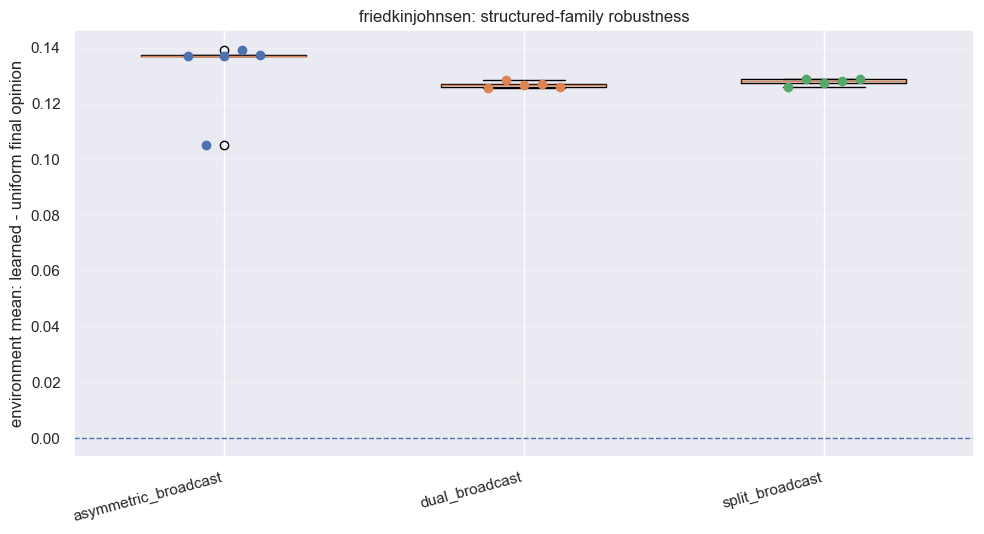

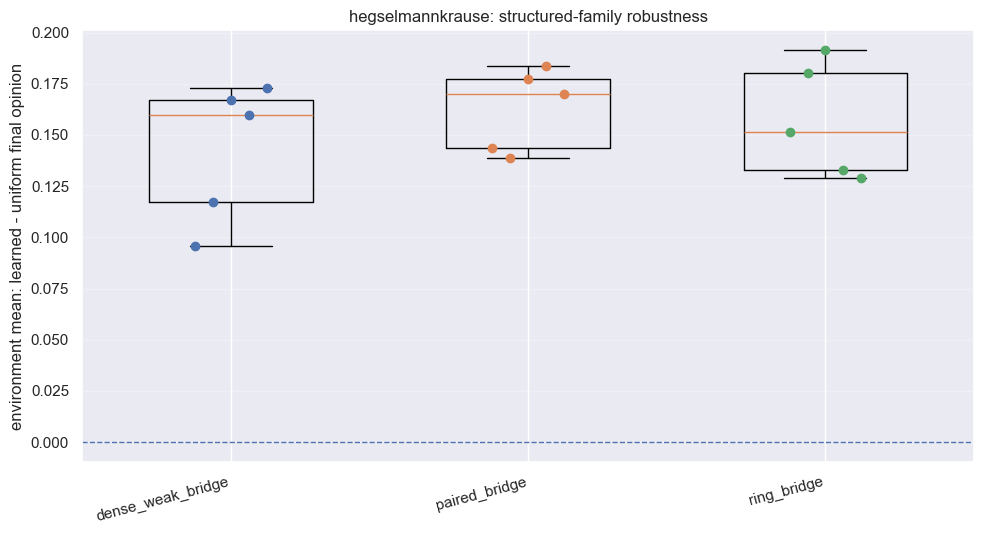

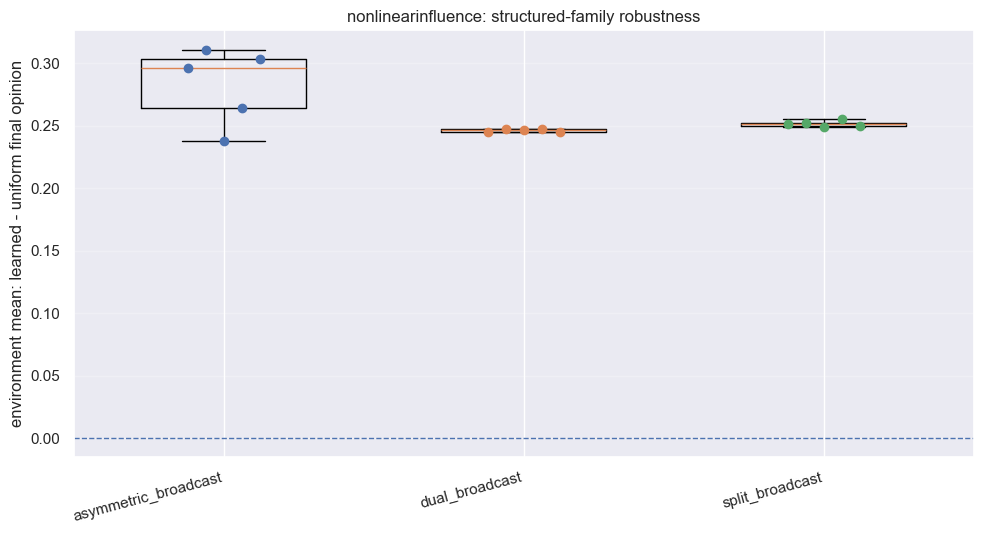

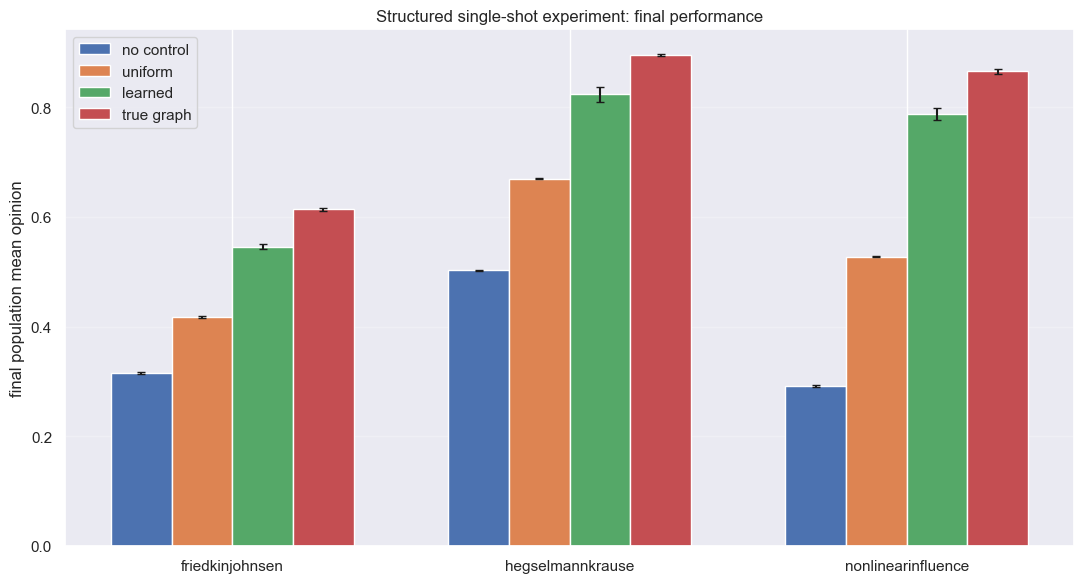

In [19]:
if not WORKER_MODE:
    # 1) Environment-level learned-minus-uniform gaps, grouped by family.
    for dynamics in env_level_df["dynamics"].unique():
        subset = env_level_df[
            env_level_df["dynamics"] == dynamics
        ].copy()

        families = list(
            subset["family"].drop_duplicates()
        )

        fig, ax = plt.subplots(figsize=(10, 5.5))

        positions = np.arange(len(families))
        values = [
            subset.loc[
                subset["family"] == family,
                "learned_gap_final",
            ].to_numpy()
            for family in families
        ]

        ax.boxplot(
            values,
            positions=positions,
            widths=0.55,
        )

        for position, family_values in zip(
            positions,
            values,
        ):
            x = np.full(
                len(family_values),
                position,
                dtype=float,
            )
            offsets = np.linspace(
                -0.12,
                0.12,
                len(family_values),
            )
            ax.scatter(
                x + offsets,
                family_values,
                zorder=3,
            )

        ax.axhline(
            0.0,
            linestyle="--",
            linewidth=1.0,
        )
        ax.set_xticks(positions)
        ax.set_xticklabels(
            families,
            rotation=15,
            ha="right",
        )
        ax.set_ylabel(
            "environment mean: learned - uniform final opinion"
        )
        ax.set_title(
            f"{dynamics}: structured-family robustness"
        )
        ax.grid(axis="y", alpha=0.25)
        fig.tight_layout()
        fig.savefig(
            RESULTS_DIR
            / f"{dynamics}_family_gap_boxplot.png",
            dpi=180,
            bbox_inches="tight",
        )
        plt.show()
        plt.close(fig)

    # 2) Final mean-opinion comparison by dynamics.
    policy_plot_rows = []

    for dynamics in env_level_df["dynamics"].unique():
        group = env_level_df[
            env_level_df["dynamics"] == dynamics
        ]

        for policy, column in [
            ("no control", "no_control_final_mean"),
            ("uniform", "uniform_final_mean"),
            ("learned", "learned_final_mean"),
            ("true graph", "oracle_final_mean"),
        ]:
            mean, ci = mean_ci95(
                group[column].to_numpy()
            )
            policy_plot_rows.append(
                {
                    "dynamics": dynamics,
                    "policy": policy,
                    "mean": mean,
                    "ci": ci,
                }
            )

    policy_plot_df = pd.DataFrame(
        policy_plot_rows
    )

    dynamics_order = list(
        env_level_df["dynamics"].unique()
    )
    policy_order = [
        "no control",
        "uniform",
        "learned",
        "true graph",
    ]

    fig, ax = plt.subplots(figsize=(11, 6))
    width = 0.18
    x = np.arange(len(dynamics_order))

    for p_index, policy in enumerate(policy_order):
        rows = (
            policy_plot_df[
                policy_plot_df["policy"] == policy
            ]
            .set_index("dynamics")
            .loc[dynamics_order]
        )

        ax.bar(
            x
            + (p_index - 1.5) * width,
            rows["mean"],
            width=width,
            yerr=rows["ci"],
            capsize=3,
            label=policy,
        )

    ax.set_xticks(x)
    ax.set_xticklabels(dynamics_order)
    ax.set_ylabel("final population mean opinion")
    ax.set_title(
        "Structured single-shot experiment: final performance"
    )
    ax.grid(axis="y", alpha=0.25)
    ax.legend()
    fig.tight_layout()
    fig.savefig(
        RESULTS_DIR / "structured_final_performance.png",
        dpi=180,
        bbox_inches="tight",
    )
    plt.show()
    plt.close(fig)

## HK bridge-activation result

In [20]:
if not WORKER_MODE:
    hk_specs = [
        spec
        for spec in ENVIRONMENT_SPECS
        if spec["dynamics"] == "hegselmannkrause"
    ]

    hk_rows = []

    for spec in hk_specs:
        environment_id = spec["environment_id"]

        uniform_rollout = baseline_rollouts[
            environment_id
        ]["uniform"]
        oracle_rollout = baseline_rollouts[
            environment_id
        ]["true_graph"]

        uniform_bridge = hk_bridge_metrics(
            uniform_rollout,
            spec["A"],
        )
        oracle_bridge = hk_bridge_metrics(
            oracle_rollout,
            spec["A"],
        )

        learned_bridge_campaigns = []

        for learning_seed in LEARNING_SEEDS:
            learned_bridge = hk_bridge_metrics(
                learned_rollouts[
                    (environment_id, learning_seed)
                ],
                spec["A"],
            )
            learned_bridge_campaigns.append(
                learned_bridge[
                    "first_bridge_campaign"
                ]
            )

        hk_rows.append(
            {
                "environment_id": environment_id,
                "family": spec["family"],
                "environment_seed": spec["environment_seed"],
                "uniform_first_bridge_campaign": (
                    uniform_bridge[
                        "first_bridge_campaign"
                    ]
                ),
                "learned_first_bridge_campaign_mean": float(
                    np.nanmean(
                        learned_bridge_campaigns
                    )
                ),
                "oracle_first_bridge_campaign": (
                    oracle_bridge[
                        "first_bridge_campaign"
                    ]
                ),
            }
        )

    hk_bridge_df = pd.DataFrame(hk_rows)

    display(
        hk_bridge_df.groupby(
            "family",
            as_index=False,
        )[
            [
                "uniform_first_bridge_campaign",
                "learned_first_bridge_campaign_mean",
                "oracle_first_bridge_campaign",
            ]
        ]
        .mean()
        .round(4)
    )

    hk_bridge_df.to_csv(
        RESULTS_DIR / "hk_bridge_activation.csv",
        index=False,
    )

,family,uniform_first_bridge_campaign,learned_first_bridge_campaign_mean,oracle_first_bridge_campaign
0,dense_weak_bridge,15.0,3.8000,1.0
1,paired_bridge,15.0,3.0667,1.0
2,ring_bridge,15.2,3.0667,1.0


## Predetermined representative trajectory examples

To avoid selecting the prettiest realization after seeing the results, the
trajectory figures use a fixed canonical family and environment seed:

- HK: `ring_bridge`, environment seed 0;
- FJ: `asymmetric_broadcast`, environment seed 0;
- nonlinear influence: `asymmetric_broadcast`, environment seed 0.

Among the three learned training seeds for that *already fixed environment*, the
seed whose final mean is closest to the three-seed median is shown.

In [21]:
CANONICAL_ENVIRONMENTS = {
    "hegselmannkrause": (
        "ring_bridge",
        0,
    ),
    "friedkinjohnsen": (
        "asymmetric_broadcast",
        0,
    ),
    "nonlinearinfluence": (
        "asymmetric_broadcast",
        0,
    ),
}


def find_spec(
    dynamics: str,
    family: str,
    environment_seed: int,
) -> dict[str, Any]:
    matches = [
        spec
        for spec in ENVIRONMENT_SPECS
        if (
            spec["dynamics"] == dynamics
            and spec["family"] == family
            and spec["environment_seed"]
            == environment_seed
        )
    ]

    if len(matches) != 1:
        raise RuntimeError(
            f"Expected one spec, got {len(matches)}"
        )

    return matches[0]


def representative_learning_seed(
    environment_id: str,
) -> int:
    rows = (
        learned_df[
            learned_df["environment_id"]
            == environment_id
        ]
        .sort_values("final_mean")
        .reset_index(drop=True)
    )

    median_value = float(
        rows["final_mean"].median()
    )

    index = (
        rows["final_mean"]
        - median_value
    ).abs().idxmin()

    return int(
        rows.loc[index, "learning_seed"]
    )


def plot_all_nodes(
    rollout: dict[str, Any],
    *,
    dynamics: str,
    title: str,
    filename: str,
) -> None:
    times, states, _ = fine_trajectory(rollout)

    fig, ax = plt.subplots(figsize=(13, 7))

    if dynamics == "hegselmannkrause":
        hubs = {
            HK_LOW_HUB,
            HK_HIGH_HUB,
        }
        low_nodes = set(HK_LOW_CLUSTER)
    else:
        hubs = set(BROADCAST_HUBS)
        low_nodes = set()

    for node in range(N):
        is_hub = node in hubs

        if dynamics == "hegselmannkrause":
            linestyle = (
                "-"
                if node in low_nodes
                else "--"
            )
        else:
            linestyle = (
                "-"
                if is_hub
                else "--"
            )

        ax.plot(
            times,
            states[:, node],
            linewidth=3.0 if is_hub else 1.1,
            linestyle=linestyle,
            label=(
                f"node {node}"
                + (" | hub" if is_hub else "")
            ),
        )

    ax.axhline(
        TARGET,
        linestyle=":",
        linewidth=1.2,
        label="target",
    )
    ax.set_ylim(0.0, 1.02)
    ax.set_xlabel("time")
    ax.set_ylabel("opinion")
    ax.set_title(title)
    ax.grid(alpha=0.25)
    ax.legend(
        bbox_to_anchor=(1.02, 1.0),
        loc="upper left",
        fontsize=8,
    )

    fig.tight_layout()
    fig.savefig(
        RESULTS_DIR / filename,
        dpi=180,
        bbox_inches="tight",
    )
    plt.show()
    plt.close(fig)

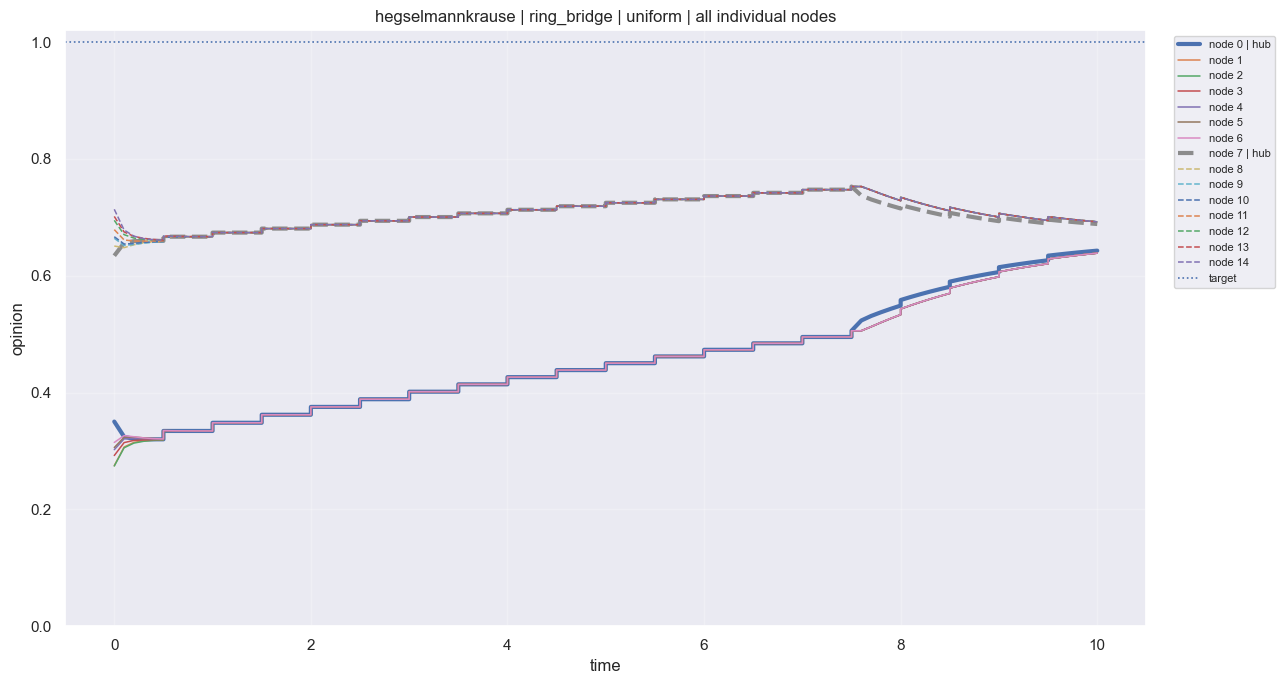

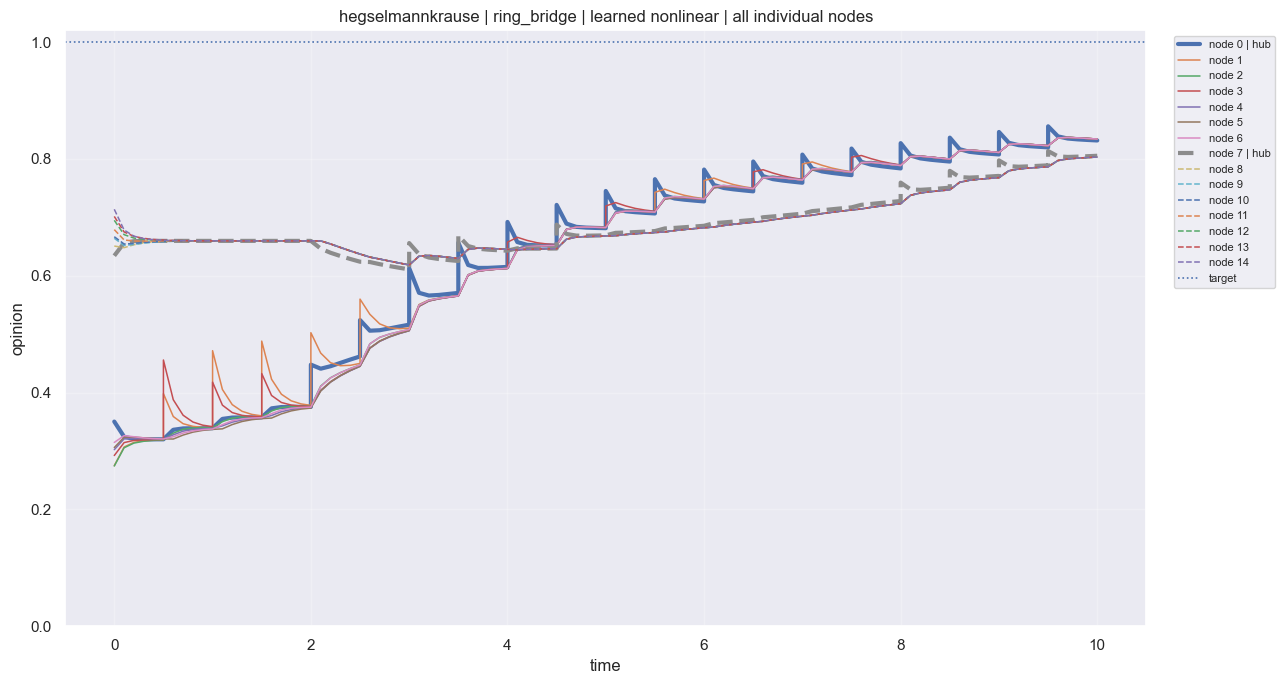

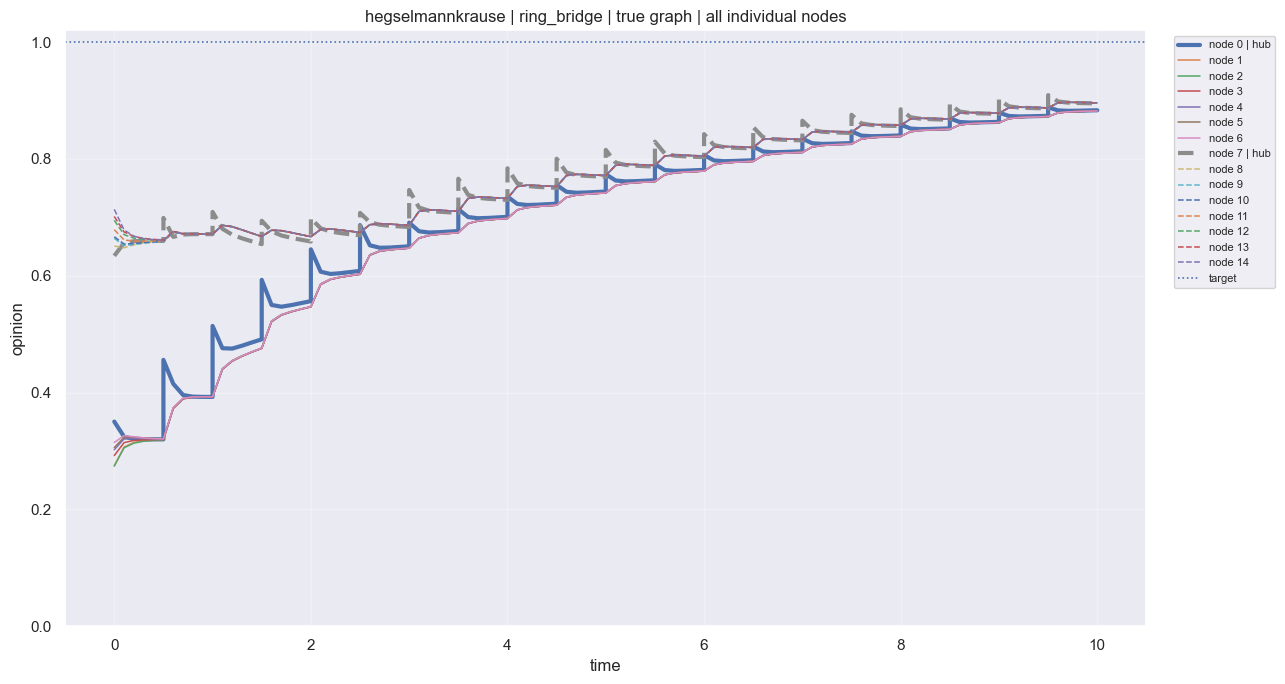

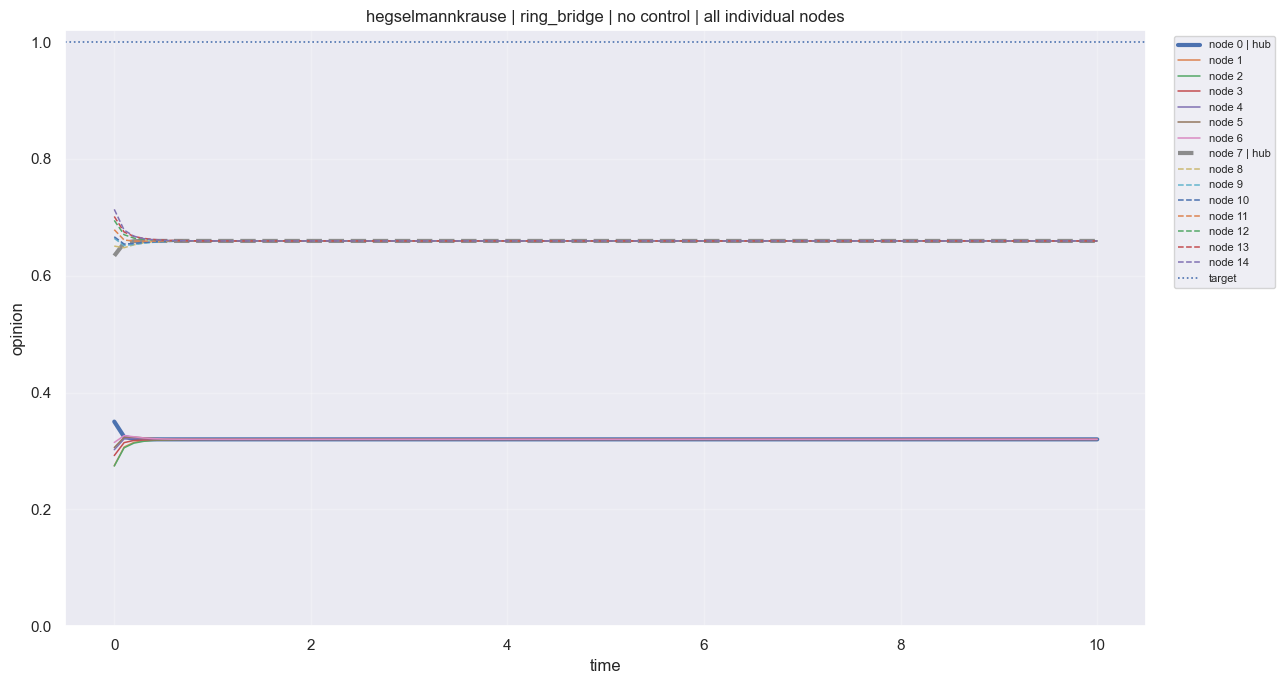

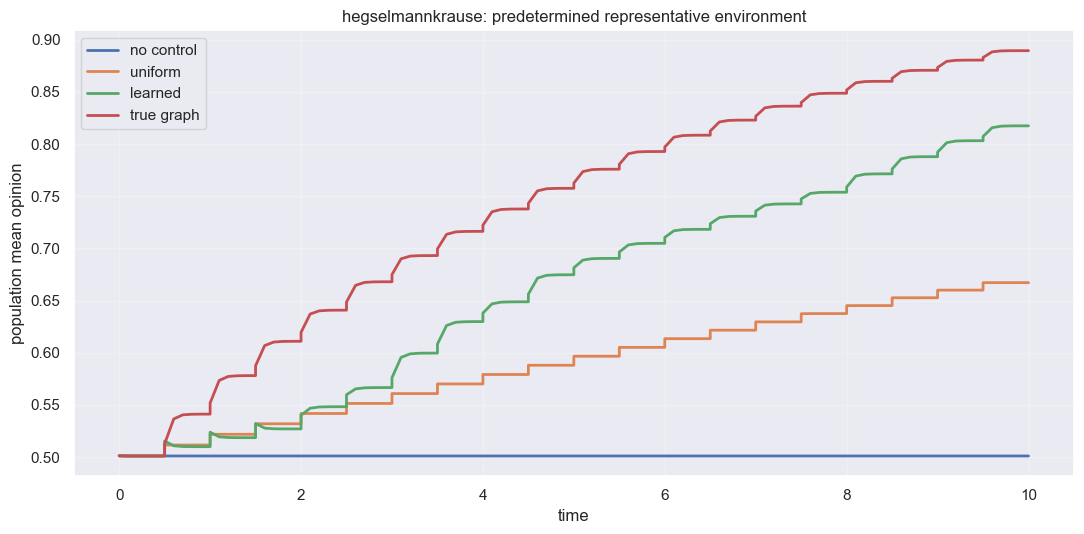

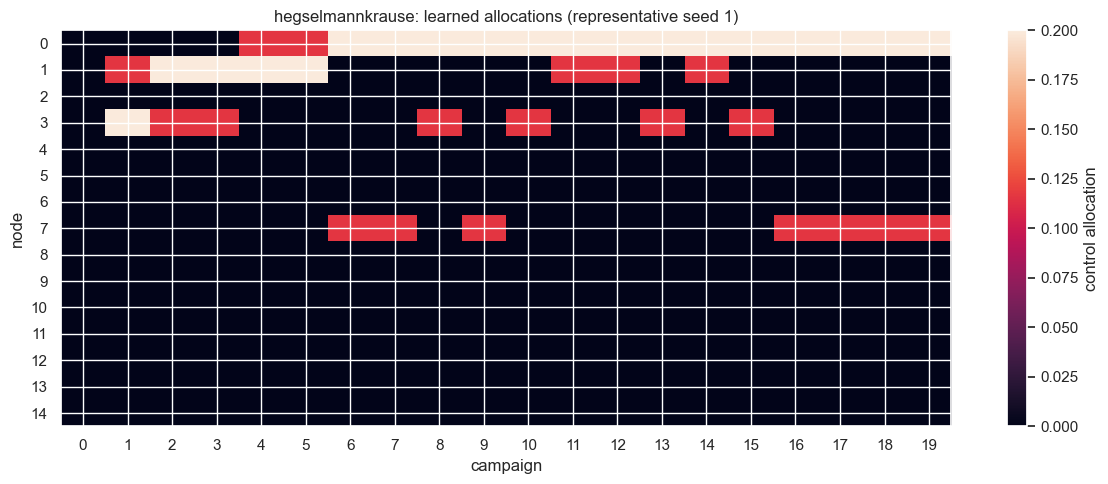

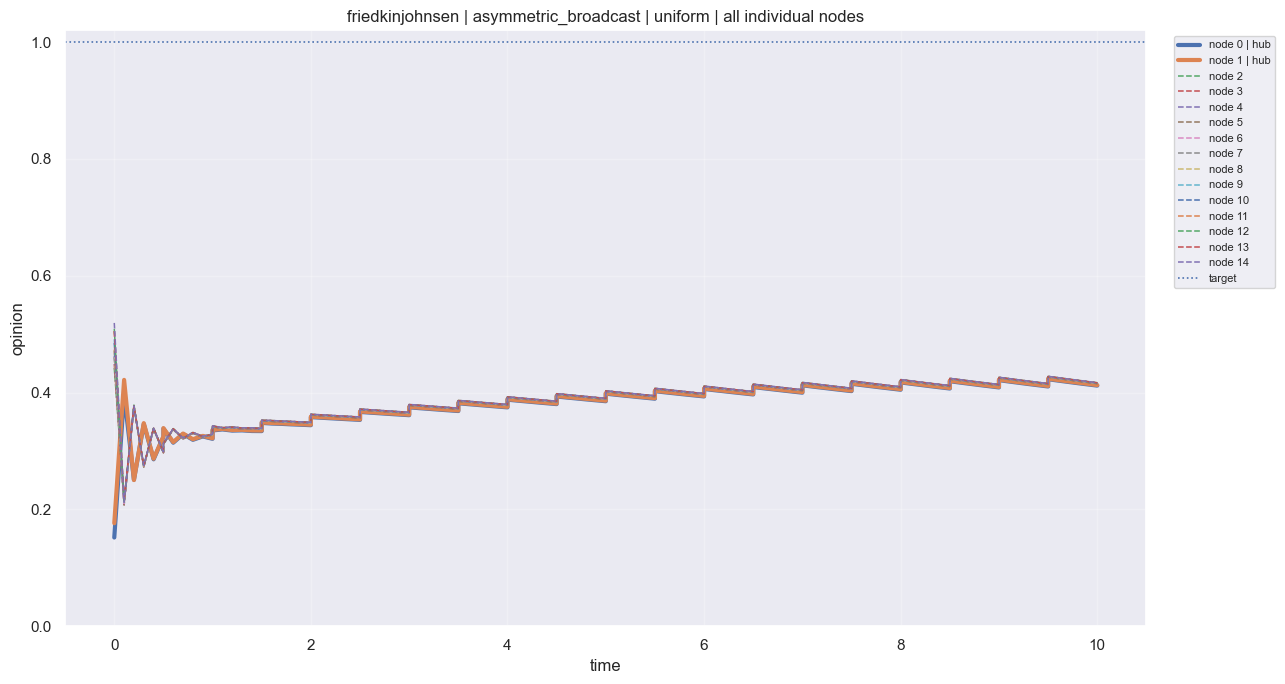

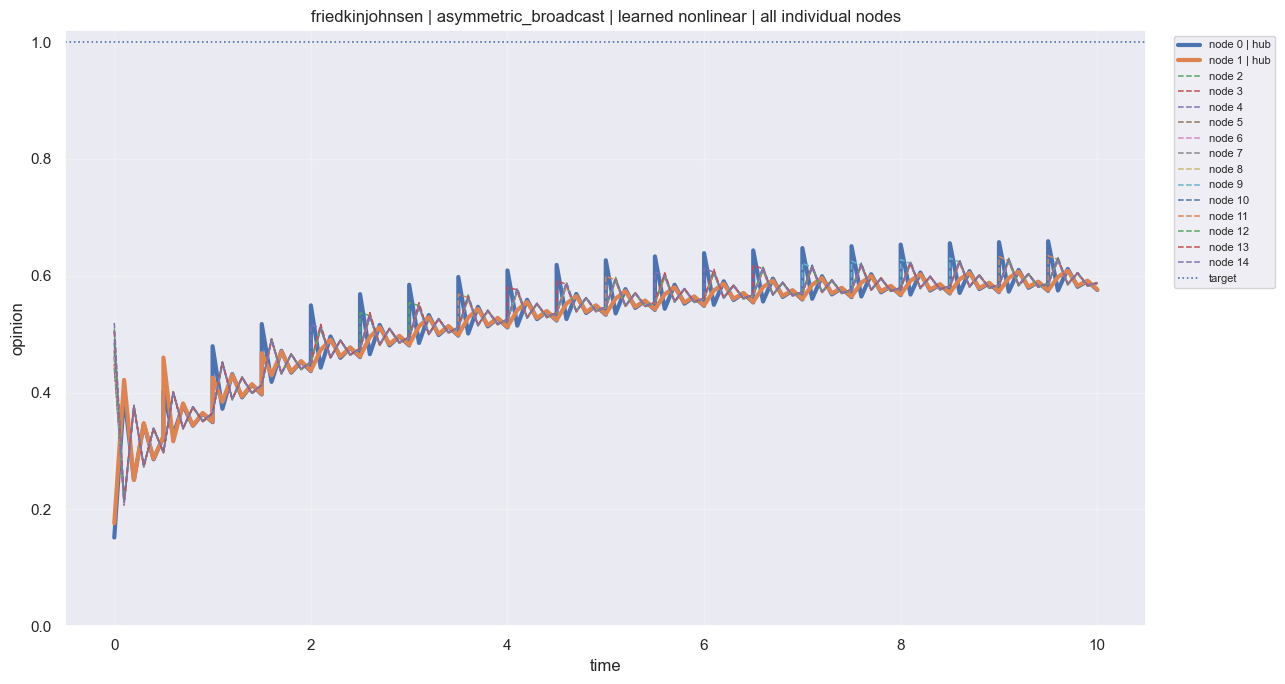

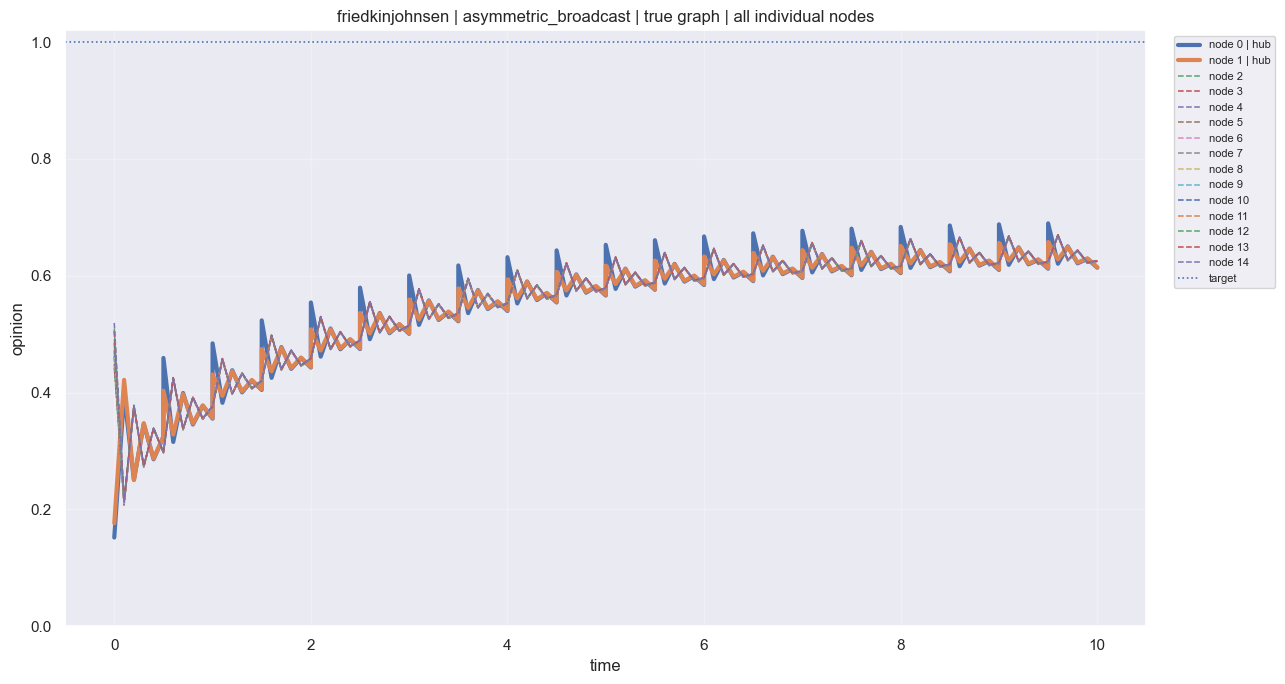

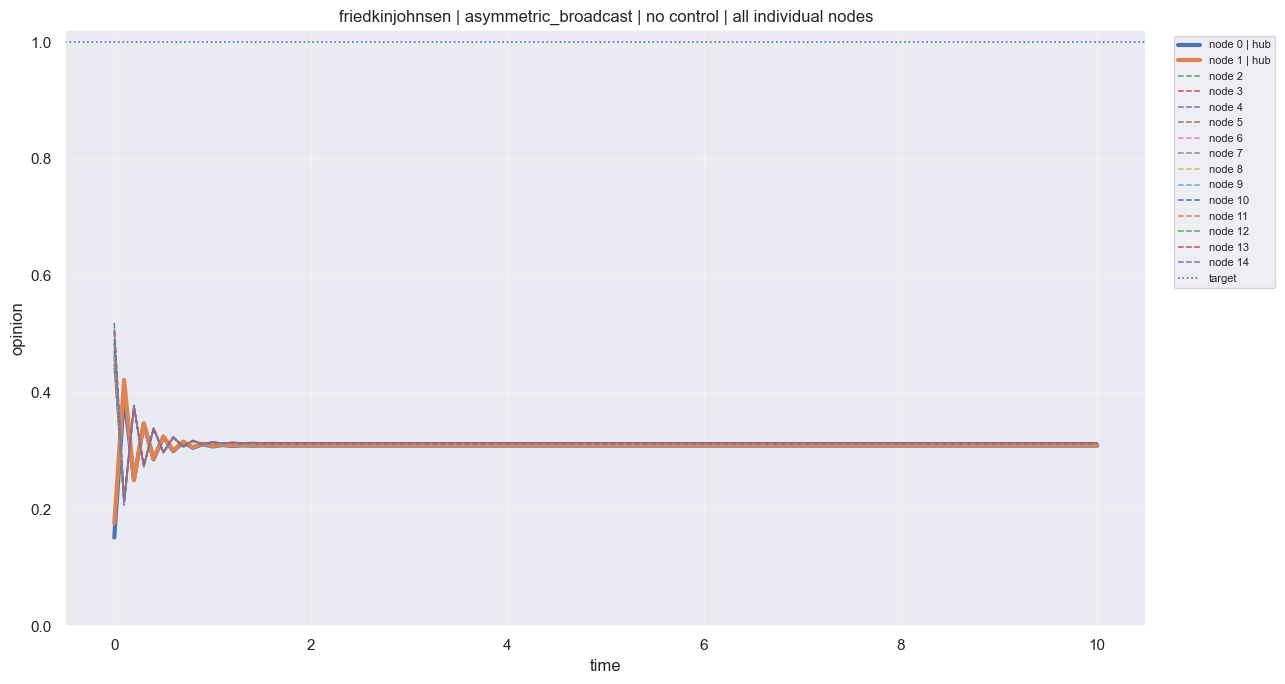

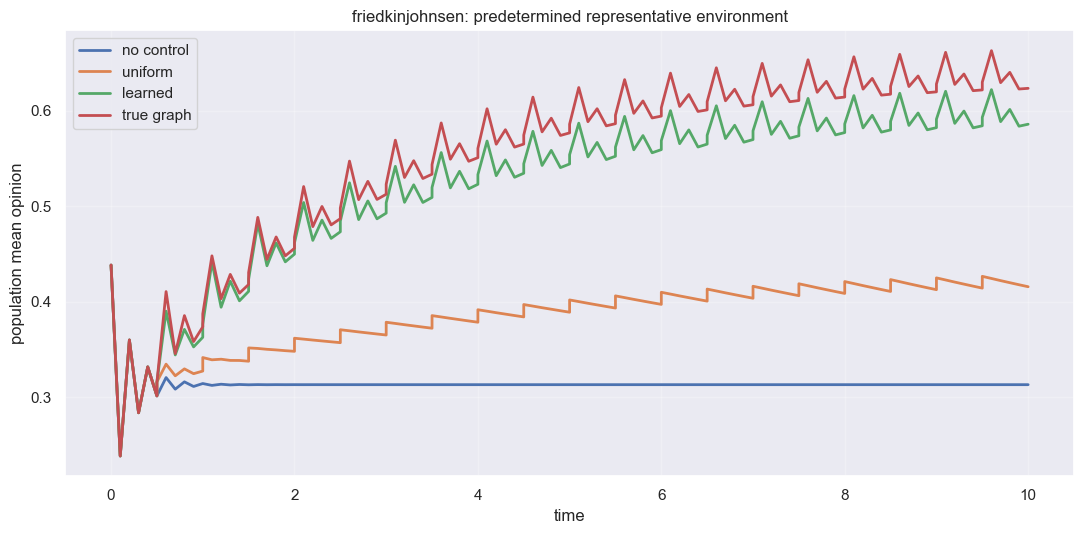

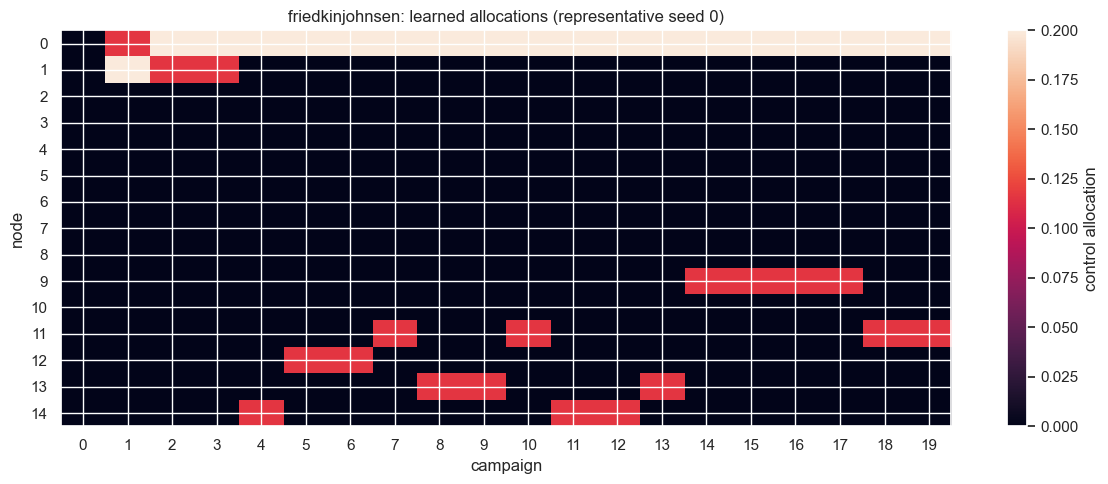

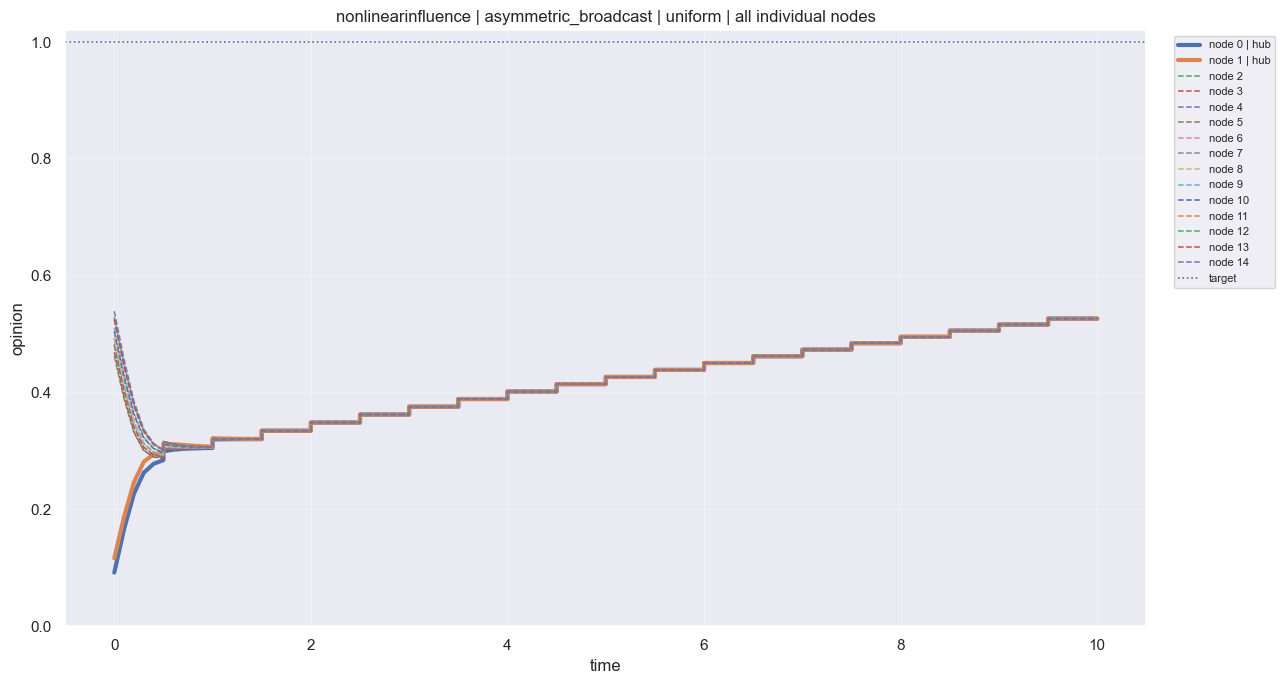

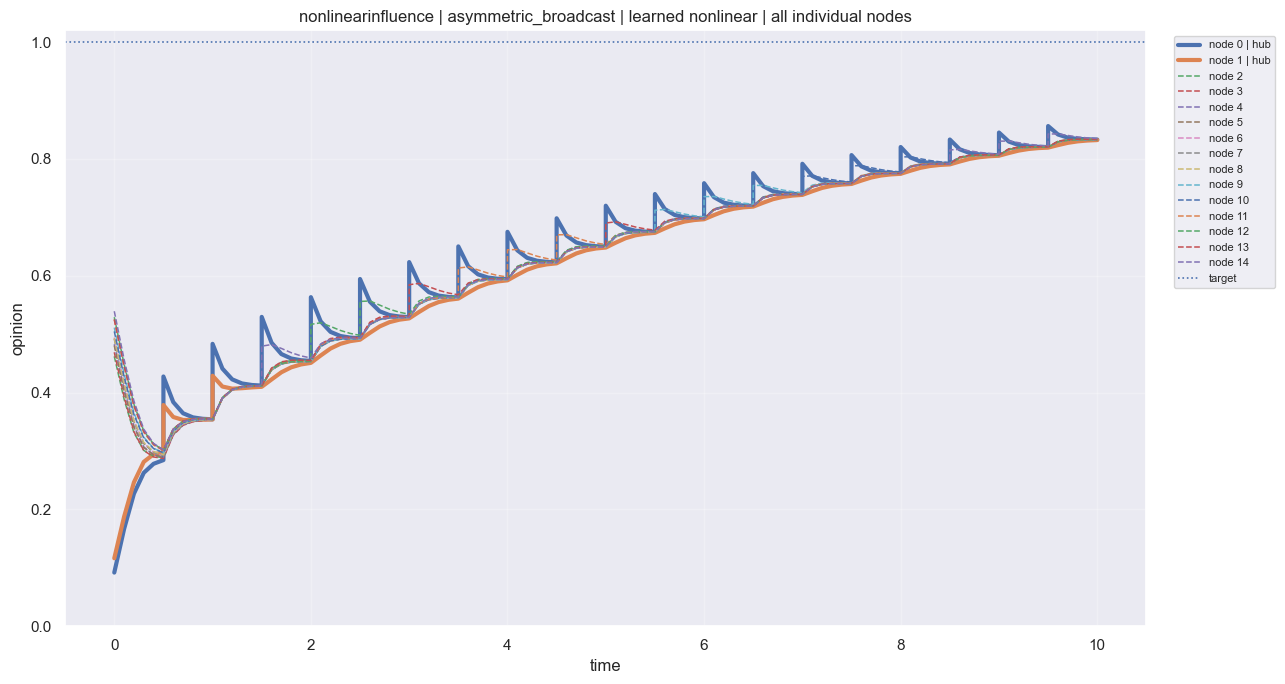

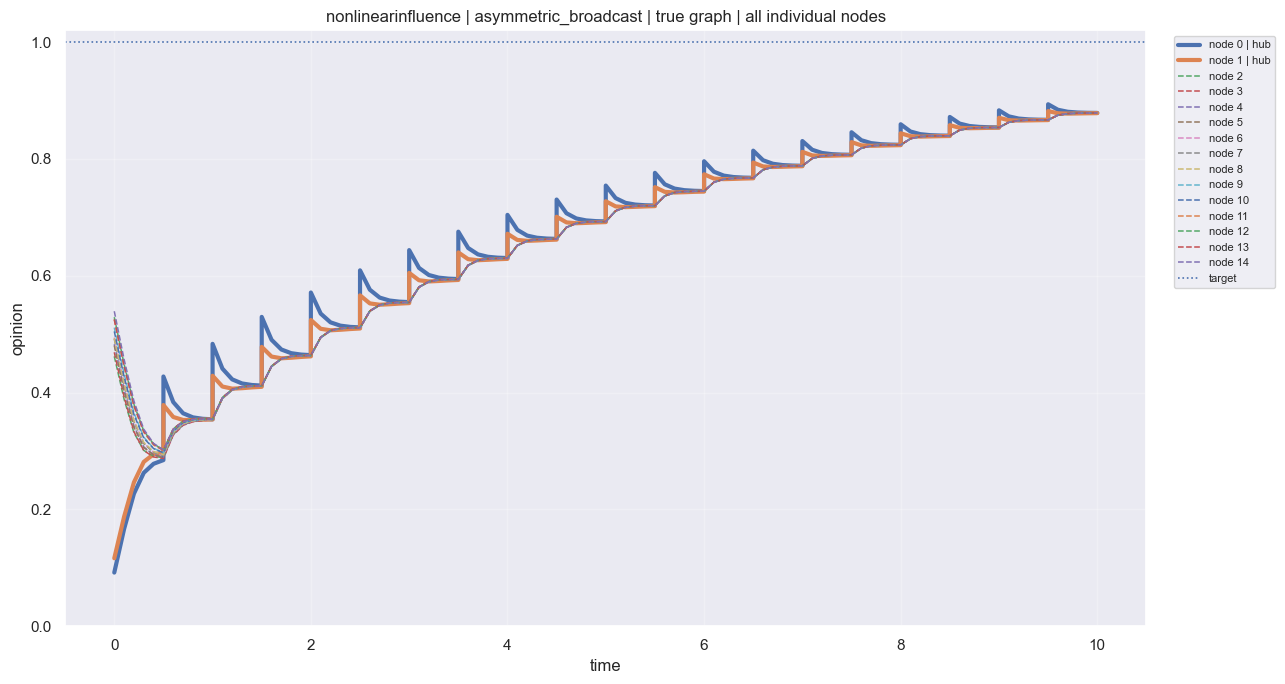

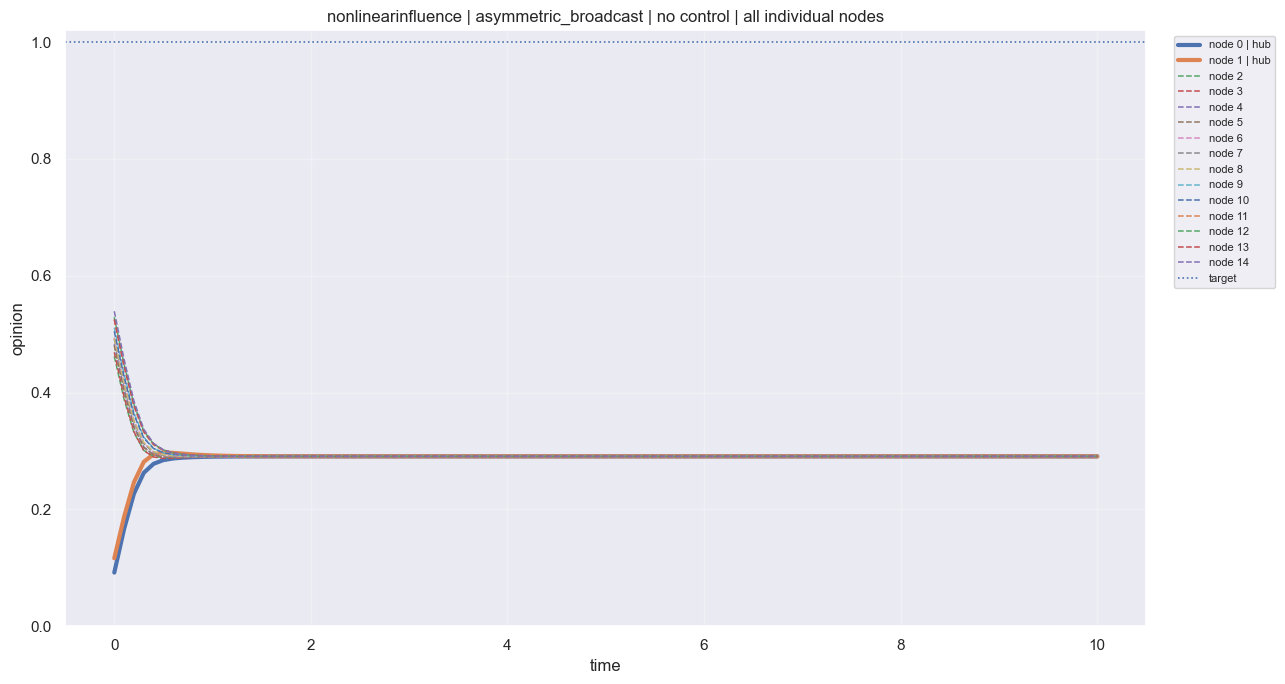

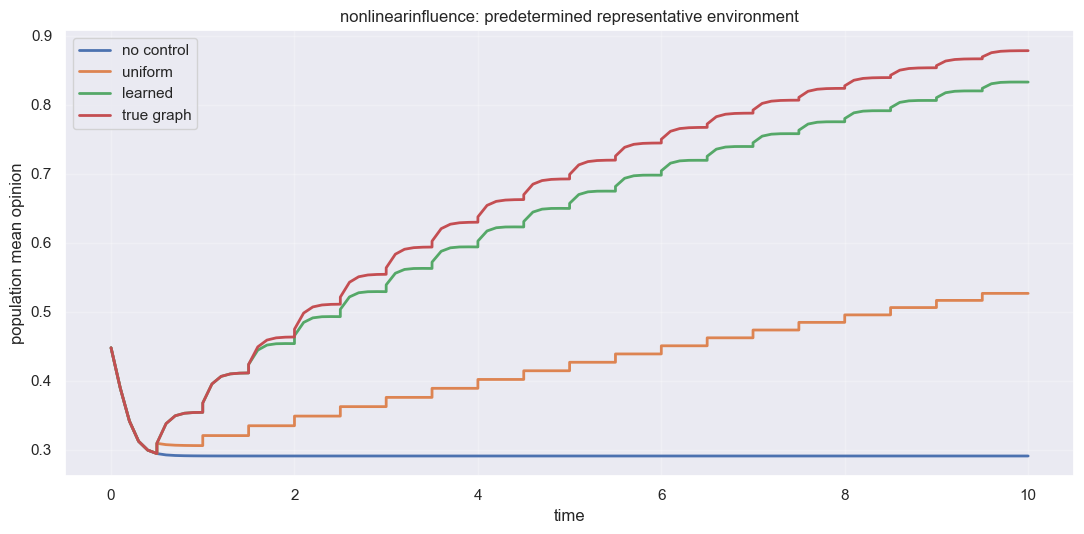

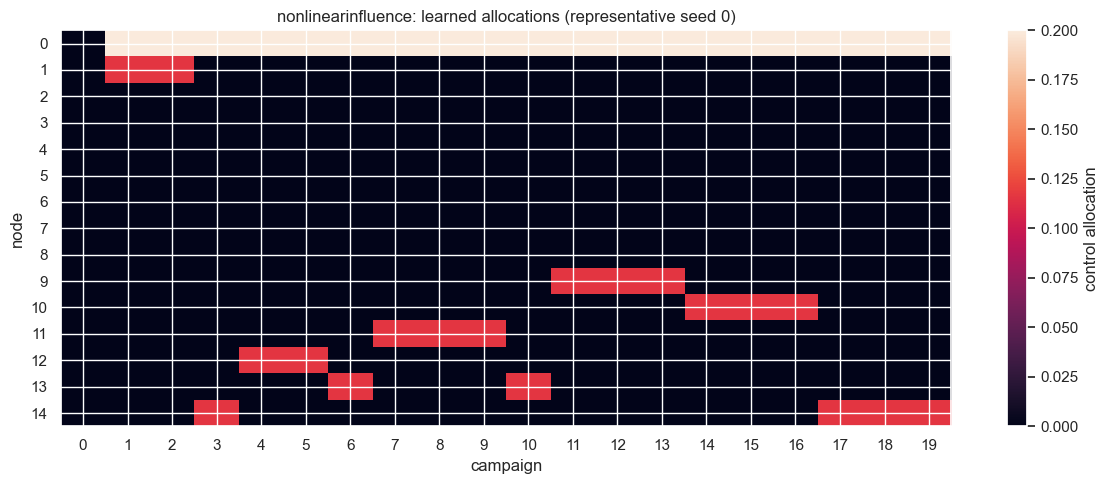

,dynamics,family,environment_seed,representative_learning_seed
0,hegselmannkrause,ring_bridge,0,1
1,friedkinjohnsen,asymmetric_broadcast,0,0
2,nonlinearinfluence,asymmetric_broadcast,0,0


In [22]:
if not WORKER_MODE:
    representative_rows = []

    for dynamics, (
        family,
        environment_seed,
    ) in CANONICAL_ENVIRONMENTS.items():
        spec = find_spec(
            dynamics,
            family,
            environment_seed,
        )
        environment_id = spec["environment_id"]

        rep_seed = representative_learning_seed(
            environment_id
        )
        learned_rollout = learned_rollouts[
            (environment_id, rep_seed)
        ]

        baselines = baseline_rollouts[
            environment_id
        ]

        representative_rows.append(
            {
                "dynamics": dynamics,
                "family": family,
                "environment_seed": environment_seed,
                "representative_learning_seed": rep_seed,
            }
        )

        for policy, rollout, label in [
            (
                "uniform",
                baselines["uniform"],
                "uniform",
            ),
            (
                "learned",
                learned_rollout,
                "learned nonlinear",
            ),
            (
                "true_graph",
                baselines["true_graph"],
                "true graph",
            ),
            (
                "no_control",
                baselines["no_control"],
                "no control",
            ),
        ]:
            plot_all_nodes(
                rollout,
                dynamics=dynamics,
                title=(
                    f"{dynamics} | {family} | "
                    f"{label} | all individual nodes"
                ),
                filename=(
                    f"{dynamics}_canonical_all_nodes_{policy}.png"
                ),
            )

        # Population-mean comparison.
        fig, ax = plt.subplots(figsize=(11, 5.5))

        for rollout, label in [
            (baselines["no_control"], "no control"),
            (baselines["uniform"], "uniform"),
            (learned_rollout, "learned"),
            (baselines["true_graph"], "true graph"),
        ]:
            times, states, _ = fine_trajectory(rollout)
            ax.plot(
                times,
                states.mean(axis=1),
                linewidth=2.0,
                label=label,
            )

        ax.set_xlabel("time")
        ax.set_ylabel("population mean opinion")
        ax.set_title(
            f"{dynamics}: predetermined representative environment"
        )
        ax.grid(alpha=0.25)
        ax.legend()
        fig.tight_layout()
        fig.savefig(
            RESULTS_DIR
            / f"{dynamics}_canonical_mean_comparison.png",
            dpi=180,
            bbox_inches="tight",
        )
        plt.show()
        plt.close(fig)

        # Learned allocation heatmap.
        actions = np.asarray(
            learned_rollout["actions"],
            dtype=float,
        )

        fig, ax = plt.subplots(figsize=(12, 5))
        image = ax.imshow(
            actions.T,
            aspect="auto",
            interpolation="nearest",
        )
        ax.set_xlabel("campaign")
        ax.set_ylabel("node")
        ax.set_xticks(
            np.arange(actions.shape[0])
        )
        ax.set_yticks(np.arange(N))
        ax.set_title(
            f"{dynamics}: learned allocations "
            f"(representative seed {rep_seed})"
        )
        fig.colorbar(
            image,
            ax=ax,
            label="control allocation",
        )
        fig.tight_layout()
        fig.savefig(
            RESULTS_DIR
            / f"{dynamics}_canonical_learned_actions.png",
            dpi=180,
            bbox_inches="tight",
        )
        plt.show()
        plt.close(fig)

    representative_df = pd.DataFrame(
        representative_rows
    )
    display(representative_df)

    representative_df.to_csv(
        RESULTS_DIR / "representative_runs.csv",
        index=False,
    )

## Final audit table

In [23]:
if not WORKER_MODE:
    audit = pd.DataFrame(
        [
            {
                "study_name": STUDY_NAME,
                "git_commit": GIT_COMMIT,
                "config_hash": CONFIG_HASH,
                "implementation_hash": IMPLEMENTATION_HASH,
                "distinct_environments": len(ENVIRONMENT_SPECS),
                "learning_seeds_per_environment": len(LEARNING_SEEDS),
                "learned_runs": len(learned_df),
                "baseline_rollouts": len(baseline_df),
                "exploration_campaigns": EXPLORATION_CAMPAIGNS,
                "campaign_0_passive": True,
                "controlled_campaigns": NUM_CAMPAIGNS - 1,
                "lambda_mix": LAMBDA_MIX,
            }
        ]
    )

    display(audit)

    audit.to_csv(
        RESULTS_DIR / "experiment_audit.csv",
        index=False,
    )

    (
        RESULTS_DIR / "ANALYSIS_COMPLETE.json"
    ).write_text(
        json.dumps(
            _json_safe(
                audit.iloc[0].to_dict()
            ),
            indent=2,
            sort_keys=True,
        ),
        encoding="utf-8",
    )

    print("Analysis complete:", RESULTS_DIR)

,study_name,git_commit,config_hash,implementation_hash,distinct_environments,learning_seeds_per_environment,learned_runs,baseline_rollouts,exploration_campaigns,campaign_0_passive,controlled_campaigns,lambda_mix
0,structured_mechanism_full_multiseed,ca3199a,fc2caeefe6117b541e8a18620c0fd8eca9aec0e2233beb...,e37ff12c7c61152c99e440164add5b0916cec589ccc7cc...,45,3,135,135,0,True,19,0.7


Analysis complete: d:\Work\repos\RL\unknown_graph_networks\opinion_dynamics\experiments\results\experiment_2026_08_17_structured_mechanism_full_multiseed
